# Every figure of the paper, in one notebook

One run of this notebook, top to bottom, writes the ten figures of
the paper and nothing else:

| figure | section |
| --- | --- |
| `EOS_pe.pdf` | 2 |
| `QMcoreEOSs.pdf` | 3 |
| `multiBand_crop.pdf` | 4 |
| `multiband_singleEOS.pdf` | 5 |
| `quadVsChar_ellipse.pdf` | 6 |
| `peakVsChar.pdf` | 6 |
| `quadVsChar_conditioned.pdf` | 6 |
| `tnuc_likelihood.pdf` | 7 |
| `strainCurves.pdf` | 8 |
| `plotBubbles_crop.pdf` | 9 |

The drawing code is the code used for the paper, unchanged in everything
that reaches the page. What has changed is the housekeeping, and only
because ten figures now share one kernel:

* **Style.** A section cannot inherit the type sizes of the
  one above it.
* **Names.** Each section prefixes its own data with two letters -- `pe_`,
  `qm_`, `mb_`, `se_`, `fq_`, `rs_`, `sc_`, `bb_` -- because several of the
  source notebooks called their arrays `likelihood` and meant different
  things by it. Only what is genuinely shared is shared, and that is
  collected in section 1.
* **Where the files go.** From here, `save_figure` writes
  straight into `results/figures`.

It reads three things and nothing else: the sampler run in `data/sample`, what
`run_sweep` wrote in `results/`, and the detector curves in
`data/noise_curves`.

## 1. Common ground

Paths, the house style, the likelihood colour scale, the tick style, and the
detector sensitivity curves. Everything below this section draws on it.

In [19]:
import json
import shutil
import subprocess
import tempfile
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.ticker import (
    AutoMinorLocator,
    FixedFormatter,
    FixedLocator,
    FuncFormatter,
    LogFormatterMathtext,
    LogLocator,
    MaxNLocator,
    NullFormatter,
    ScalarFormatter,
)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)


# -----------------------------------------------------------------------------
# Where everything is
# -----------------------------------------------------------------------------
# This notebook lives in scripts/, next to the modules/ package, and reads the
# repository beside it: the sampler run in data/sample, the detector curves in
# data/noise_curves, and what run_sweep wrote in results/.
NOTEBOOK_DIR = Path.cwd()

REPOSITORY = NOTEBOOK_DIR.parent

# The detector curves, under the name the source notebooks gave the directory
data_dir = REPOSITORY / "data" / "noise_curves"

EOS_DATA = REPOSITORY / "data"

ACCEPTED_DIR = EOS_DATA / "sample"

RESULTS = REPOSITORY / "results" / "results_0.h5"

BUBBLES = REPOSITORY / "results" / "bubbles_883.h5"

FIGURES = REPOSITORY / "results" / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

from modules import plot_settings as ps
from modules import utils as u


print(f"notebook   {NOTEBOOK_DIR}")
print(f"data       {EOS_DATA}")
print(f"results    {RESULTS}")
print(f"figures    {FIGURES}")

notebook   c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\scripts
data       c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\data
results    c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\results_0.h5
figures    c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures


In [20]:
# -----------------------------------------------------------------------------
# Style
# -----------------------------------------------------------------------------
# The three settings every figure of the paper shares. The type sizes are not
# among them: each figure is printed at a different fraction of the page and
# sets its own, which is what use_style takes.
#
# text.usetex is on deliberately. modules.plot_settings.configure_plot_style()
# sets it back to False, which is why none of the source notebooks called it
# and why this one does not either.
BASE_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
}


def use_style(**overrides):
    """Start from the matplotlib defaults, then the house style, then these.

    Called at the top of every section, so that a figure never inherits the
    type sizes of the one drawn before it.
    """
    plt.rcdefaults()
    plt.rcParams.update(BASE_RC)
    plt.rcParams.update(overrides)


# -----------------------------------------------------------------------------
# Saving
# -----------------------------------------------------------------------------
# Two of the figures go into the draft cropped. bbox_inches="tight" has already
# taken the margin off, and pdfcrop takes off what is left; without pdfcrop on
# the path the uncropped figure is written under the cropped name, which is a
# slightly looser figure and not a missing one.
PDFCROP = shutil.which("pdfcrop")

if PDFCROP is None:
    print(
        "pdfcrop was not found on the path, so the two _crop figures will be "
        "written uncropped. MiKTeX and TeX Live both ship it."
    )


def save_figure(fig, name, crop=False):
    """Write one figure into results/figures, at the resolution of the paper."""
    target = FIGURES / name

    if not crop:
        fig.savefig(target, dpi=300, bbox_inches="tight")

    else:
        # The uncropped figure is an intermediate and not a file anyone wants
        # next to the others, so it is made and dropped in a temporary place.
        with tempfile.TemporaryDirectory() as scratch:
            uncropped = Path(scratch) / name

            fig.savefig(uncropped, dpi=300, bbox_inches="tight")

            if PDFCROP is None:
                shutil.copyfile(uncropped, target)
            else:
                subprocess.run(
                    [PDFCROP, str(uncropped), str(target)],
                    check=True,
                    stdout=subprocess.DEVNULL,
                )

    print(f"saved {target}")

    return target

In [21]:
# -----------------------------------------------------------------------------
# The likelihood colour scale
# -----------------------------------------------------------------------------
# One scale for the whole paper. The bins are
#
#     [0, 10^-3), [10^-3, 10^-2), [10^-2, 0.1), ..., [0.8, 1]
#
# which is one grey bin for the models that are only context and nine
# increasingly dark blue ones for the rest.
#
# Sections 2 and 3 use modules.plot_settings.colormap instead, which is the
# same scale built in the EOSsampler tree; they were written against it and
# there is no reason to make them differ from the supplemental figures that
# share it.
LIKELIHOOD_BOUNDS = np.array([
    0.0, 1.0e-3, 1.0e-2, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0,
])

LIKELIHOOD_COLOURS = ["lightgrey"] + list(plt.cm.Blues(np.linspace(0.30, 0.95, 9)))

LIKELIHOOD_TICKLABELS = [
    r"$0$", r"$10^{-3}$", r"$10^{-2}$", r"$0.1$", r"$0.2$",
    r"$0.3$", r"$0.4$", r"$0.5$", r"$0.6$", r"$0.8$", r"$1$",
]


def likelihood_colormap():
    """The discrete normalized-likelihood colour map and its normalization."""
    cmap = mcolors.ListedColormap(LIKELIHOOD_COLOURS)

    norm = mcolors.BoundaryNorm(LIKELIHOOD_BOUNDS, cmap.N, clip=True)

    return cmap, LIKELIHOOD_BOUNDS, norm


def add_likelihood_colorbar(
    fig,
    ax,
    fraction=0.025,
    pad=0.025,
    labelsize=11,
    aspect=None,
):
    """Draw that scale as a colorbar beside ax.

    labelsize is the one thing that changes from figure to figure: the figures
    are printed at different fractions of the page, so the numbers beside the
    bar are set in different sizes to come out alike.
    """
    cmap, bounds, norm = likelihood_colormap()

    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_map.set_array([])

    options = dict(
        orientation="vertical",
        fraction=fraction,
        pad=pad,
        label=r"${\rm Normalised~likelihood}$",
    )

    if aspect is not None:
        options["aspect"] = aspect

    cbar = fig.colorbar(scalar_map, ax=ax, **options)

    cbar.set_ticks(bounds)
    cbar.set_ticklabels(LIKELIHOOD_TICKLABELS)

    cbar.ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        left=True,
        right=True,
        labelleft=False,
        labelright=True,
        labelsize=labelsize,
        length=4,
        width=0.8,
        zorder=20,
    )

    cbar.outline.set_linewidth(1.0)
    cbar.outline.set_zorder(20)

    return cmap, bounds, norm, cbar


# The two fitted lines of sections 6 and 7 carry these, so that a dotted dark
# grey line means the prior and a dashed red one the posterior in every figure
# of the paper.
PRIOR_COLOUR = "dimgray"

POSTERIOR_COLOUR = "red"

In [22]:
# -----------------------------------------------------------------------------
# Axes
# -----------------------------------------------------------------------------
def raise_axis_decorations(ax, zorder=20):
    """Draw tick marks, tick labels, and spines above all data curves."""
    ax.set_axisbelow(False)

    ax.xaxis.set_zorder(zorder)
    ax.yaxis.set_zorder(zorder)

    for axis in (ax.xaxis, ax.yaxis):
        for tick in axis.get_major_ticks():
            tick.tick1line.set_zorder(zorder)
            tick.tick2line.set_zorder(zorder)
            tick.label1.set_zorder(zorder + 1)
            tick.label2.set_zorder(zorder + 1)

        for tick in axis.get_minor_ticks():
            tick.tick1line.set_zorder(zorder)
            tick.tick2line.set_zorder(zorder)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_zorder(zorder)


def logarithmic_ticks(ax):
    """Labelled major ticks at every decade, bare minor ticks in between."""
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(LogLocator(base=10.0, numticks=100))

        axis.set_major_formatter(LogFormatterMathtext(base=10.0))

        axis.set_minor_locator(
            LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
        )

        axis.set_minor_formatter(NullFormatter())

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        left=True,
        right=True,
        bottom=True,
        top=True,
        labelleft=True,
        labelright=False,
        labelbottom=True,
        labeltop=False,
        length=6,
        width=1.0,
        zorder=20,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        left=True,
        right=True,
        bottom=True,
        top=True,
        labelleft=False,
        labelright=False,
        labelbottom=False,
        labeltop=False,
        length=3,
        width=0.8,
        zorder=20,
    )

    raise_axis_decorations(ax, zorder=20)


def linear_ticks(ax):
    """The tick style of logarithmic_ticks, on linear axes."""
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(MaxNLocator(nbins=5))

        # A common power in the corner, rather than a row of long numbers
        formatter = ScalarFormatter(useMathText=True)

        formatter.set_powerlimits((-3, 3))

        axis.set_major_formatter(formatter)

        axis.set_minor_locator(AutoMinorLocator(5))

        axis.set_minor_formatter(NullFormatter())

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        left=True,
        right=True,
        bottom=True,
        top=True,
        labelleft=True,
        labelright=False,
        labelbottom=True,
        labeltop=False,
        length=6,
        width=1.0,
        zorder=20,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        left=True,
        right=True,
        bottom=True,
        top=True,
        labelleft=False,
        labelright=False,
        labelbottom=False,
        labeltop=False,
        length=3,
        width=0.8,
        zorder=20,
    )

    raise_axis_decorations(ax, zorder=20)


def report_outside(ax, x, y, what):
    """Count the drawable points that fall outside the axis window."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    drawable = (
        np.isfinite(x) & np.isfinite(y) & (x > 0.0) & (y > 0.0)
    )

    inside = (
        (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)
    )

    outside = int(np.count_nonzero(drawable & ~inside))

    if outside:
        print(
            f"{outside} of the {int(np.count_nonzero(drawable))} {what} lie "
            "outside the plotted window; widen the limits above to see them"
        )

    return outside

In [23]:
# -----------------------------------------------------------------------------
# Weighted statistics
# -----------------------------------------------------------------------------
# Used by sections 6 and 7, which had a copy each. The likelihood belongs to an
# equation of state and every model of it inherits the same number. Used as a
# weight it says how much each point counts for, which is not the same as
# multiplying the value by it: the point keeps its own frequency and counts for
# w of a point rather than for one.
def effective_size(weights):
    """Kish's effective sample size, (sum w)^2 / sum w^2.

    How many equally weighted points the weighted sample is worth. These
    likelihoods are skewed enough that it is a few per cent of the count, and
    it is what a standard error is divided by rather than the raw number of
    points: an ensemble of which a handful of equations of state carry nearly
    all the likelihood is not as many measurements as it has members.
    """
    weights = np.asarray(weights, dtype=float)

    return float(np.sum(weights) ** 2 / np.sum(weights**2))


def weighted_quantile(values, quantiles, weights):
    """Quantiles of a weighted sample, interpolated.

    Sorted by value, the weights accumulated, and the quantile read off where
    the running weight crosses it. Each point sits at the middle of its own
    slab of weight, so equal weights give the ordinary quantile back.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    order = np.argsort(values)
    values, weights = values[order], weights[order]

    running = np.cumsum(weights)

    return np.interp(
        quantiles, (running - 0.5 * weights) / running[-1], values
    )

In [24]:
# -----------------------------------------------------------------------------
# The detector sensitivity curves
# -----------------------------------------------------------------------------
# Read once, here, and drawn by sections 4, 5 and 8. Sections 4 and 5 draw all
# five; section 8 draws only the two that reach the MHz band.
def load_numeric(filename, delimiter=None):
    """Load a numerical table and remove empty or non-numerical rows."""
    data = np.genfromtxt(
        data_dir / filename,
        delimiter=delimiter,
        comments="#",
        invalid_raise=False,
    )

    data = np.atleast_2d(data)

    # Remove rows containing no finite numerical entries
    data = data[np.any(np.isfinite(data), axis=1)]

    return data


def clean_xy(data, xcol=0, ycol=1):
    """Select finite, positive x and y values for logarithmic plots."""
    x = np.asarray(data[:, xcol], dtype=float)
    y = np.asarray(data[:, ycol], dtype=float)

    mask = (
        np.isfinite(x) & np.isfinite(y) & (x > 0.0) & (y > 0.0)
    )

    x = x[mask]
    y = y[mask]

    order = np.argsort(x)

    return x[order], y[order]


MWB = load_numeric("MWB-DMR-res.csv", delimiter=",")

LEV = load_numeric("levitatedSensors_100m.csv", delimiter=",")

ET = load_numeric("ET-0001A-18_ETDSensitivityCurveTxtFile.txt")

LIGO5 = load_numeric("LIGO5.tad")

CE = load_numeric("cosmic_explorer_strain.txt")


# Mathematica equivalent:
# Import[...][[300 ;; -200]]
LIGO5 = LIGO5[299:-199]


# Extract plotting columns
mwbf, mwbstrain = clean_xy(MWB)
levf, levstrain = clean_xy(LEV)
etf, etstrain = clean_xy(ET)
cef, cestrain = clean_xy(CE)

# Mathematica equivalent:
# LIGO5[[;;, {1, 4}]]
ligof, ligostrain = clean_xy(LIGO5, xcol=0, ycol=3)


print(
    f"sensitivity curves: MWB {mwbf.size}, OLS {levf.size}, ET {etf.size}, "
    f"CE {cef.size}, aLIGO {ligof.size} points"
)

sensitivity curves: MWB 87, OLS 87, ET 3000, CE 1000, aLIGO 7572 points


In [25]:
# -----------------------------------------------------------------------------
# The swept results
# -----------------------------------------------------------------------------
# results_0.h5 is what run_sweep wrote for data/sample/0.h5. It holds one group
# per equation of state under "eos", carrying that equation of state's raw
# likelihood in "like" and the datasets the Julia side saved beside it --
# "curves", "characteristic", "quadrupole", "peaks", "rows", "snr". The
# top-level "like_range" carries the largest likelihood of the accepted sample,
# and that is what every likelihood below is divided by, so that a normalized
# likelihood of, say, 0.5 means the same thing in every figure.
#
# Julia writes column-major and h5py reads row-major, so an n-by-2 table on the
# Julia side arrives here with 2 rows: "characteristic", "quadrupole" and
# "peaks" are (2, models), row 0 the frequency and row 1 the strain; "curves"
# is (models, 2, points) and "rows" is (models, 12).
ROW_COLUMNS = (
    "accretion",
    "sigma_MeV_fm2",
    "Lambda_MeV",
    "v_wall",
    "fpeak_MHz",
    "R_bubble_m",
    "R_core_m",
    "N_bubbles",
    "M_nuc",
    "Lambda_q_nuc",
    "Lambda_h_nuc",
    "t_nuc_ms",
)


with h5py.File(RESULTS, "r") as h5:
    MAX_LIKELIHOOD = float(h5["like_range"][1])

    GW_KEYS = sorted(h5["eos"], key=int)


def gw_groups(datasets):
    """(key, likelihood, {name: array}) for every equation of state swept."""
    names = (datasets,) if isinstance(datasets, str) else tuple(datasets)

    with h5py.File(RESULTS, "r") as h5:

        for key in GW_KEYS:
            group = h5["eos"][key]

            yield (
                key,
                float(group["like"][()]),
                {name: group[name][...] for name in names},
            )


def gw_group(key, datasets):
    """The same, for the one equation of state named by `key`."""
    names = (datasets,) if isinstance(datasets, str) else tuple(datasets)

    with h5py.File(RESULTS, "r") as h5:
        group = h5["eos"][str(key)]

        return (
            float(group["like"][()]),
            {name: group[name][...] for name in names},
        )


def gw_normalize(likelihood):
    """Put a likelihood on the [0, 1] scale of the whole results file.

    NaNs become 0 and small numerical excursions past either end are clipped.
    """
    scaled = np.asarray(likelihood, dtype=float) / MAX_LIKELIHOOD

    return np.clip(np.nan_to_num(scaled), 0.0, 1.0)


print(f"{len(GW_KEYS)} equations of state in {RESULTS.name}")

print(f"largest likelihood of the set: {MAX_LIKELIHOOD:.6e}")


110 equations of state in results_0.h5
largest likelihood of the set: 1.789709e-03


## The accepted ensemble, sections 2 and 3

The `EOSsampler` run in `data/sample`, restricted to the sample that
`NS_FOPT.jl/FilterEOS.jl` accepted: the ids it listed, file by file, in
`accepted.json` next to it. That json *is* the selection quoted in the draft
-- the EOSs with a stable quark-matter core whose hadronic branch admits the
delayed transition.

The two figures read different quantities of the same models, so they make a
pass each.

In [26]:
# The ids kept by FilterEOS.jl, one list per file of the run
ACCEPTED_JSON = ACCEPTED_DIR / "accepted.json"

# Posterior quantity used for colouring: "ptot", "pGW_xray", "pGW", "pM"
COLOR_BY = "ptot"


def ens_load_accepted(path):
    """{file name: sorted ids}, the files in the numeric order of the run."""

    with open(path) as stream:
        accepted = json.load(stream)

    return {
        name: sorted(accepted[name])
        for name in sorted(accepted, key=lambda name: int(Path(name).stem))
    }


def ens_likelihood(params, mode):
    """The posterior weight of one sample, read from its `params` group."""

    if mode in ("ptot", "pM", "pGW"):
        return float(params[mode][0])

    if mode == "pGW_xray":

        px = np.asarray(params["pXray"][:], dtype=float)
        positive = px[px > 0]

        return float(params["pGW"][0]) * (
            float(np.prod(positive)) if positive.size else 1.0
        )

    raise ValueError(f"Unknown COLOR_BY mode: {mode}")


ens_accepted = ens_load_accepted(ACCEPTED_JSON)

print(
    f"{len(ens_accepted)} files, "
    f"{sum(len(ids) for ids in ens_accepted.values()):,} accepted EOSs"
)

1 files, 119 accepted EOSs


## 2. `EOS_pe.pdf` -- the $p(e)$ ensemble

The ensemble goes in as two `LineCollection`s rather than as one line per
model: one flat grey layer for the models below the first colour
bound, which are only context, and one for the rest, ordered by increasing
weight so that the most likely EOSs end up on top. Both stay under the
constraint bands. The EOS of `PE_INSET_EOS` is drawn on top of everything
instead, so that the model of the inset can be followed across the whole
panel.

In [27]:
use_style(**{
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "figure.titlesize": 16,
})

PE_FIGSIZE = (5, 4)

# The EOS of the inset, drawn over the ensemble in the main panel as well:
#   None         the most likely EOS of the whole sample
#   (file, id)   one specific sample; the file takes 31, "31" or "31.h5"
PE_INSET_EOS = (0, 883)

# Its colours, in the main panel and in the inset: the confined branch, the
# deconfined one past the transition, and the jump from the first to the second
PE_CONFINED = "limegreen"
PE_DECONFINED = "darkorange"
PE_TRANSITION = "dimgray"

# Which of the four lines of that EOS covers which: the largest number is drawn
# last and so ends up on top. Equal values are settled by the order in which
# matplotlib meets them, which is the order above, so keep them apart.
PE_STACKING = {
    "confined": 0.0,
    "deconfined": 0.1,
    "metastable": 0.2,
    "transition": 0.3,
}

# Whether the inset also shows EOSext, the branch the EOS would have followed
# had it not made the transition.
PE_SHOW_EXTENSION = True

# What the inset draws: PE_INSET_Y against PE_INSET_X, any two of the datasets
# the sampler writes next to each EOS -- "mu", "e", "p", "n", "cs2"
PE_INSET_X = "mu"
PE_INSET_Y = "p"

# Its range, and its major ticks; None leaves the ticks to matplotlib
PE_INSET_XLIM = (1000, 1600)
PE_INSET_YLIM = (5, 600)

PE_INSET_XTICKS = [1000, 1200, 1400, 1600]
PE_INSET_YTICKS = [10, 30, 100, 300]

# Legend of the inset: one entry per phase, since it is the colour that tells
# them apart. The dashed metastable branch is left to the caption.
PE_PHASE_LABELS = (r"$\mathrm{hadron}$", r"$\mathrm{quark}$")

# Symbol and unit of every dataset the inset can draw, "None" for a pure
# number. The labels of both axes and of the transition line are built from
# this, so changing PE_INSET_X/PE_INSET_Y is all a different inset takes.
PE_AXES = {
    "mu": (r"\mu", r"\mathrm{MeV}"),
    "e": (r"e", r"\mathrm{MeV/fm}^{3}"),
    "p": (r"p", r"\mathrm{MeV/fm}^{3}"),
    "n": (r"n", r"\mathrm{fm}^{-3}"),
    "cs2": (r"c_s^2", None),
}

In [28]:
def pe_load(directory, accepted, mode):
    """The p(e) curves, the posterior weights and the (file, id) of each."""

    e_blocks = []
    p_blocks = []
    weights = []
    keys = []

    for name, ids in accepted.items():

        path = directory / name

        if not path.exists():
            print(f"  {name} missing, skipping")
            continue

        with h5py.File(path, "r") as h5:

            # float32 halves the footprint of the ~5x10^4 curves and is well
            # beyond what a rasterised line needs.
            e_blocks.append(
                np.array([h5[f"{i}/EOS/e"][:] for i in ids], dtype=np.float32)
            )

            p_blocks.append(
                np.array([h5[f"{i}/EOS/p"][:] for i in ids], dtype=np.float32)
            )

            weights += [ens_likelihood(h5[f"{i}/params"], mode) for i in ids]
            keys += [(name, i) for i in ids]

    return (
        np.vstack(e_blocks),
        np.vstack(p_blocks),
        np.asarray(weights, dtype=float),
        keys,
    )


def pe_select(spec, keys, weights):
    """Row of the loaded arrays that PE_INSET_EOS asks for."""

    if spec is None:
        return int(np.argmax(weights))

    name, index = spec
    name = str(name)

    key = (name if name.endswith(".h5") else f"{name}.h5", int(index))

    if key not in keys:
        raise ValueError(f"EOS {key[1]} of {key[0]} is not in the accepted sample")

    return keys.index(key)


def pe_read_branches(directory, key, x, y, extension=True):
    """(x, y) of one model, cut at its transition, and its extension.

    `x` and `y` name two datasets of the `EOS` group -- "mu", "e", "p", "n",
    "cs2". What comes back is the confined branch, the jump, the deconfined
    branch, the metastable continuation of the confined one, and the `x` of
    the last point the two branches share, which is where the transition is
    marked.

    `params/muPT` is written in GeV -- tov_solver.cpp reads it straight into
    `mu_pt_gev` -- while `EOS/mu` is in MeV, hence the factor of a thousand.

    `EOSext` repeats the EOS up to the left side of the transition and then
    carries the last pre-transition sound-speed segment on to larger mu instead
    of jumping, so only the part from mu_crit upwards says anything new.
    """

    name, index = key

    with h5py.File(directory / name, "r") as h5:

        group = h5[str(index)]

        def read(table):
            return [
                np.asarray(group[f"{table}/{field}"][:], dtype=float)
                for field in ("mu", x, y)
            ]

        mu, x_eos, y_eos = read("EOS")

        mu_crit = 1.0e3 * float(group["params/muPT"][0])

        if extension and "EOSext" in group:
            mu_ext, x_ext, y_ext = read("EOSext")
        else:
            mu_ext, x_ext, y_ext = (np.empty(0), np.empty(0), np.empty(0))

    def positive(mu_, x_, y_):
        """The inset is log-log, so anything at or below zero has to go."""

        keep = np.isfinite(x_) & np.isfinite(y_) & (x_ > 0.0) & (y_ > 0.0)

        return mu_[keep], x_[keep], y_[keep]

    mu, x_eos, y_eos = positive(mu, x_eos, y_eos)
    mu_ext, x_ext, y_ext = positive(mu_ext, x_ext, y_ext)

    # The left side of the transition: mu repeats there, and "left" is both the
    # last confined point and the one the extension carries on from
    split = min(int(np.searchsorted(mu, mu_crit, side="left")), mu.size - 1)

    if mu_ext.size:

        # Start the extension on the EOS rather than next to it
        start = max(int(np.searchsorted(mu_ext, mu_crit, side="right")) - 1, 0)

        x_ext = x_ext[start:]
        y_ext = y_ext[start:]

    return {
        "confined": (x_eos[:split + 1], y_eos[:split + 1]),
        "transition": (x_eos[split:split + 2], y_eos[split:split + 2]),
        "deconfined": (x_eos[split + 1:], y_eos[split + 1:]),
        "metastable": (x_ext, y_ext),
        "crit": float(x_eos[split]),
    }


pe_e, pe_p, pe_like, pe_keys = pe_load(ACCEPTED_DIR, ens_accepted, COLOR_BY)

pe_normalized = pe_like / pe_like.max()

# The EOS of the inset, highlighted in the main panel too
pe_inset = pe_select(PE_INSET_EOS, pe_keys, pe_like)

pe_inset_curve = pe_read_branches(
    ACCEPTED_DIR,
    pe_keys[pe_inset],
    PE_INSET_X,
    PE_INSET_Y,
    PE_SHOW_EXTENSION,
)

# The same EOS in the variables of the main panel. The ensemble arrays carry it
# as well, but not the transition that cuts it in two.
pe_main_curve = pe_read_branches(
    ACCEPTED_DIR, pe_keys[pe_inset], "e", "p", extension=False
)

# 1 is the most likely EOS of the ensemble
pe_rank = 1 + int((pe_like > pe_like[pe_inset]).sum())

print(f"{pe_e.shape[0]:,} accepted EOSs")
print(f"Coloring by {COLOR_BY}; max likelihood = {pe_like.max():.6e}")
print(
    f"Inset EOS: {pe_keys[pe_inset][1]} of {pe_keys[pe_inset][0]}, "
    f"rank {pe_rank:,} by {COLOR_BY}"
)
print(f"  normalized likelihood = {pe_normalized[pe_inset]:.4g}")
print(
    f"  inset: {PE_INSET_Y} against {PE_INSET_X}, "
    f"transition at {pe_inset_curve['crit']:.2f}"
)

pe_jump = pe_main_curve["transition"][0]
print(f"  jump: e from {pe_jump[0]:.1f} to {pe_jump[-1]:.1f} MeV/fm^3")

pe_metastable = pe_inset_curve["metastable"][0]

if pe_metastable.size:
    print(
        f"  EOSext: {pe_metastable.size} points, up to "
        f"{PE_INSET_X} = {pe_metastable.max():.2f}"
    )

119 accepted EOSs
Coloring by ptot; max likelihood = 1.789709e-03
Inset EOS: 883 of 0.h5, rank 63 by ptot
  normalized likelihood = 0
  inset: p against mu, transition at 1227.00
  jump: e from 480.8 to 642.1 MeV/fm^3
  EOSext: 31 points, up to mu = 1373.17


In [29]:
def pe_add_constraint_regions(ax):

    ax.fill(
        u.cs2boundary[:, 0],
        u.cs2boundary[:, 1],
        zorder=1.4,
        facecolor=u.cs2_color,
        edgecolor=None,
    )

    ax.fill(
        u.pQCDpoints[:, 0],
        u.pQCDpoints[:, 1],
        facecolor=u.pQCD_color,
        edgecolor=None,
        zorder=1.5,
    )

    for boundary, color, alpha in (
        (u.boundary_ep_1ns_1s, u.CET_1ns_color, 1.0),
        (u.boundary_ep_2ns_1s, u.CET_2ns_color, 1.0),
        (u.boundary_ep_1ns_2s, u.CET_1ns_color, 0.5),
        (u.boundary_ep_2ns_2s, u.CET_2ns_color, 0.5),
    ):

        ax.fill(
            boundary[:, 0],
            boundary[:, 1],
            facecolor=color,
            edgecolor=None,
            zorder=1.5,
            alpha=alpha,
        )


def pe_axis_label(name):
    """The label of one dataset, out of its symbol and unit in PE_AXES."""

    symbol, unit = PE_AXES[name]

    return f"${symbol}$" if unit is None else rf"${symbol}\,[{unit}]$"


def pe_draw_branches(axes, branches, linewidth, labels=False, zorder=2):
    """One EOS coloured by phase: confined, the jump, then deconfined.

    The dashed line is the metastable continuation of the confined branch, the
    part of EOSext above the transition: the same branch carried on at its last
    sound speed, without the jump. Only the two phases carry a label, since it
    is the colour that the legend discriminates; the dashes are left to the
    caption.

    `zorder` places the four lines as a group, against everything else on the
    axes; PE_STACKING places them among themselves.
    """

    for phase, color, label in (
        ("confined", PE_CONFINED, PE_PHASE_LABELS[0]),
        ("deconfined", PE_DECONFINED, PE_PHASE_LABELS[1]),
    ):

        axes.plot(
            *branches[phase],
            color=color,
            linewidth=linewidth,
            solid_capstyle="butt",
            zorder=zorder + PE_STACKING[phase],
            label=label if labels else None,
        )

    # p is continuous across the jump, so this is a horizontal segment in the
    # p(e) panel, and a single point wherever mu or p is the abscissa
    axes.plot(
        *branches["transition"],
        color=PE_TRANSITION,
        linewidth=0.8 * linewidth,
        solid_capstyle="butt",
        zorder=zorder + PE_STACKING["transition"],
    )

    if branches["metastable"][0].size:

        axes.plot(
            *branches["metastable"],
            color=PE_CONFINED,
            linestyle="--",
            linewidth=linewidth,
            alpha=1,
            zorder=zorder + PE_STACKING["metastable"],
        )


def pe_add_inset(ax, branches):
    """PE_INSET_Y against PE_INSET_X, for the EOS picked by PE_INSET_EOS."""

    # [left, bottom, width, height]
    axins = ax.inset_axes(
        [0.53, 0.15, 0.42, 0.35],
        zorder=20,
    )

    axins.set_facecolor("white")

    axins.set_xscale("log")
    axins.set_yscale("log")

    # Inset plot range
    axins.set_xlim(*PE_INSET_XLIM)
    axins.set_ylim(*PE_INSET_YLIM)

    pe_draw_branches(axins, branches, 2, labels=True, zorder=3)

    axins.legend(
        loc="lower right",
        fontsize=8,
        frameon=False,
        handlelength=1.4,
        handletextpad=0.5,
        borderpad=0.2,
        labelspacing=0.2,
    )

    # The transition, at the PE_INSET_X of the last point the branches share
    crit = branches["crit"]

    axins.axvline(
        crit,
        color="black",
        linestyle="--",
        linewidth=1.0,
    )

    # The label goes on whichever side of the line has room: which one that is
    # depends on the EOS, and against the left frame it would run into the tick
    # labels.
    on_the_left = crit < np.sqrt(PE_INSET_XLIM[0] * PE_INSET_XLIM[1])

    axins.text(
        crit * (1.04 if on_the_left else 0.96),
        0.94,
        rf"${PE_AXES[PE_INSET_X][0]}_{{\rm crit}}$",
        transform=axins.get_xaxis_transform(),
        fontsize=10,
        ha="left" if on_the_left else "right",
        va="top",
    )

    # Labels
    axins.set_xlabel(
        pe_axis_label(PE_INSET_X),
        fontsize=11,
        labelpad=2,
    )

    axins.set_ylabel(
        pe_axis_label(PE_INSET_Y),
        fontsize=11,
        labelpad=2,
    )

    # Explicit major ticks, unless the config leaves them to matplotlib
    if PE_INSET_XTICKS is not None:
        axins.xaxis.set_major_locator(FixedLocator(PE_INSET_XTICKS))

    if PE_INSET_YTICKS is not None:
        axins.yaxis.set_major_locator(FixedLocator(PE_INSET_YTICKS))

    formatter = FuncFormatter(lambda x, pos: f"{x:g}")

    axins.xaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)

    # Minor log ticks
    axins.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
    )

    axins.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
    )

    axins.xaxis.set_minor_formatter(plt.NullFormatter())
    axins.yaxis.set_minor_formatter(plt.NullFormatter())

    # Tick style
    axins.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        labelsize=9,
        length=4,
        width=0.8,
        pad=2,
    )

    axins.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=2.5,
        width=0.6,
    )

    return axins

number of plotted models: 119
below the first colour bound: 106


saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\EOS_pe.pdf


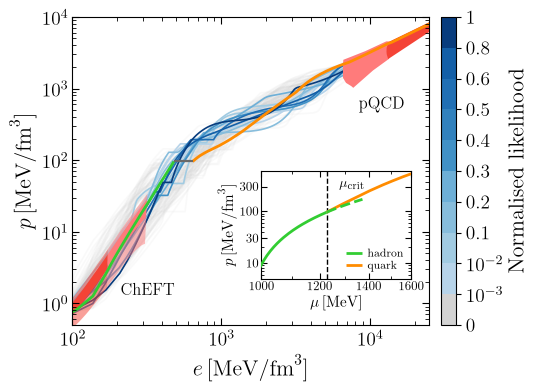

In [30]:
def pe_plot_results():

    fig, ax = plt.subplots(figsize=PE_FIGSIZE)

    # Posterior colormap + colorbar
    cmap, bounds, norm, cbar = ps.colormap(
        fig,
        ax,
        fraction=0.05,
        pad=0.03,
    )

    # ps.colormap hardcodes 11 pt; match the axes of this section
    cbar.set_label("Normalised likelihood", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    # -------------------------------------------------------------------------
    # Main axes
    # -------------------------------------------------------------------------

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(u.EMIN, u.EMAX)
    ax.set_ylim(u.PMIN, u.PMAX)

    ax.set_xlabel(r"$e\,[\mathrm{MeV/fm}^{3}]$")

    ax.set_ylabel(r"$p\,[\mathrm{MeV/fm}^{3}]$")

    ax.minorticks_on()

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        length=5,
        width=0.8,
        left=True,
        right=True,
        bottom=True,
        top=True,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3,
        width=0.6,
        left=True,
        right=True,
        bottom=True,
        top=True,
    )

    ax.yaxis.set_major_locator(
        LogLocator(
            base=10.0,
            numticks=8,
        )
    )

    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10.0,
            subs=np.arange(2, 10) * 0.1,
            numticks=80,
        )
    )

    ax.yaxis.set_minor_formatter(plt.NullFormatter())

    # Ticks and frame above the ensemble rather than under it
    ax.set_axisbelow(False)

    for spine in ax.spines.values():
        spine.set_zorder(20)

    # -------------------------------------------------------------------------
    # EOS ensemble
    # -------------------------------------------------------------------------

    threshold = bounds[1]
    faint = pe_normalized < threshold

    segments = np.stack((pe_e, pe_p), axis=-1)

    ax.add_collection(
        LineCollection(
            segments[faint],
            colors="lightgrey",
            linewidths=1.2,
            alpha=0.12,
            zorder=0,
            rasterized=True,
        ),
        autolim=False,
    )

    order = np.argsort(pe_normalized[~faint])

    ax.add_collection(
        LineCollection(
            segments[~faint][order],
            colors=cmap(norm(pe_normalized[~faint][order])),
            linewidths=1.2,
            zorder=1,
            rasterized=True,
        ),
        autolim=False,
    )

    print(f"number of plotted models: {faint.size:,}")
    print(f"below the first colour bound: {faint.sum():,}")

    # -------------------------------------------------------------------------
    # The EOS of the inset
    # -------------------------------------------------------------------------

    # Over the constraint bands as well, so that it stays readable where the
    # ensemble runs through them
    pe_draw_branches(ax, pe_main_curve, 2, zorder=2)

    # -------------------------------------------------------------------------
    # Constraint regions
    # -------------------------------------------------------------------------

    pe_add_constraint_regions(ax)

    ax.text(
        320,
        1.5,
        r"$\mathrm{ChEFT}$",
        fontsize=12,
        ha="center",
        va="center",
        zorder=10,
    )

    ax.text(
        12000,
        600,
        r"$\mathrm{pQCD}$",
        fontsize=12,
        ha="center",
        va="center",
        zorder=10,
    )

    # -------------------------------------------------------------------------
    # Inset: that EOS and its extension
    # -------------------------------------------------------------------------

    pe_add_inset(ax, pe_inset_curve)

    save_figure(fig, "EOS_pe.pdf")

    plt.show()


pe_plot_results()

## 3. `QMcoreEOSs.pdf` -- the ensemble and its quark cores

The supplemental-material figure. The two-by-three subset of
`EOSsampler/scripts/plots.ipynb` that the caption describes, with one change:
$p(e)$ has been dropped, since it is the standalone figure of section 2, and
the sound speed takes its place. The panels are

|                            |                            |          |
| -------------------------- | -------------------------- | -------- |
| $c_\mathrm{s}^2(n)$        | $\Delta n$ vs $n_{\rm PT}$ | $M(R)$   |
| $R_q$ vs $M_{\rm TOV}$     | vs $n_{\rm PT}$            | vs $\Delta n$ |

`stab > 0` counts every stable branch, so disconnected branches labelled 2
are kept; $M_{\rm TOV}$ is the largest mass over all stable configurations;
and $R_q$ is taken at that configuration. Every model is drawn the same way,
the twin/non-twin marker distinction of the older figure being unreliable.
The sound speed is broken across the mixed phase
$n_{\rm PT} \le n \le n_{\rm PT} + \Delta n$, where the Maxwell construction
leaves no single-phase matter.

In [31]:
# The settings of section 4, scaled up by a quarter: this figure is three
# panels wide and goes in at \textwidth, so it is reduced about twice as much
# as the single-column figures and would otherwise print smaller than they do.
use_style(**{
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 18,
    "figure.titlesize": 20,
})

# Two rows of three, in the aspect ratio of the figure now in the draft
QM_FIGSIZE = (15, 8)

# One marker for every model in the scatter panels
QM_MARKER, QM_MARKER_SIZE = "o", 9.0

# Axis limits. The accepted sample is far tighter than the unfiltered run the
# old figure was drawn from -- n_PT only spans 2 to 7 and Delta n 0.1 to 2 --
# so most of the published axes would now be empty.
# The EOS grid itself runs out to about 190 n_s, where it is matched to pQCD,
# so this panel is a crop whatever we do. 15 n_s is where the *stars* stop: no
# stable configuration of the ensemble has a central density above 16.7 n_s and
# 99% stay under 13.2, so nothing a star actually samples is left out.
QM_N_LIM = (0.5, 15.0)
QM_CS2_LIM = (0.0, 1.05)
QM_NPT_LIM = (1.8, 7.2)
QM_DN_LIM = (0.0, 2.1)
QM_R_LIM = (8.0, 16.0)
QM_M_LIM = (1.0, 2.8)
# Every accepted model has a quark core of at least 1.53 km and none exceeds
# 10.62, so the axis starts just under the smallest rather than at zero: the
# ensemble has no solutions to show down there.
QM_RQM_LIM = (1.4, 10.8)

# A few hundred models reach M_TOV above 3.1 and fall outside this panel. All
# of them sit below the first colour bound -- the most likely model of the
# ensemble has M_TOV = 2.75 -- so only the grey context is clipped. The M(R)
# panel likewise keeps the conventional crop and drops the low-mass tail.
QM_MTOV_LIM = (1.3, 3.1)

In [32]:
def qm_stable_branches(stab):
    """Index arrays of each stable branch, one per positive stability label."""

    branches = []

    for label in np.unique(stab):

        if label <= 0:
            continue

        index = np.where(stab == label)[0]

        if index.size >= 2:
            branches.append(index)

    return branches


def qm_stable_mtov_index(M, stab):
    """Index of the largest mass over all stable branches.

    Every accepted model has at least one stable configuration -- FilterEOS.jl
    requires it -- so this never comes back empty for the ids we read.
    """

    stable = np.where(np.asarray(stab) > 0)[0]

    return int(stable[np.argmax(M[stable])])


def qm_load(directory, accepted, mode):
    """The curves, the scalars and the posterior weight of every accepted id."""

    n_blocks, cs2_blocks = [], []
    weights, npt, dn, mtov, rqm, mr = [], [], [], [], [], []

    for name, ids in accepted.items():

        path = directory / name

        if not path.exists():
            print(f"  {name} missing, skipping")
            continue

        n_file, cs2_file = [], []

        with h5py.File(path, "r") as h5:

            for i in ids:

                group = h5[str(i)]

                n_file.append(group["EOS/n"][:] / u.ns)
                cs2_file.append(group["EOS/cs2"][:])

                M = group["TOV/M"][:]
                R = group["TOV/R"][:]
                stab = group["TOV/stab"][:]
                Rqm = group["TOV/Rqm"][:]

                index = qm_stable_mtov_index(M, stab)

                weights.append(ens_likelihood(group["params"], mode))
                npt.append(float(group["params/nPTl"][0]) / u.ns)
                dn.append(float(group["params/dn"][0]))

                mtov.append(float(M[index]))
                rqm.append(float(Rqm[index]))

                # Each stable branch as its own (R, M) polyline, so a model with
                # a disconnected branch comes out as the two curves it is
                mr.append([
                    np.column_stack((R[b], M[b])).astype(np.float32)
                    for b in qm_stable_branches(stab)
                ])

        # float32 halves the footprint of the ~5x10^4 curves and is well beyond
        # what a rasterised line needs.
        n_blocks.append(np.array(n_file, dtype=np.float32))
        cs2_blocks.append(np.array(cs2_file, dtype=np.float32))

    return {
        "n": np.vstack(n_blocks),
        "cs2": np.vstack(cs2_blocks),
        "like": np.asarray(weights, dtype=float),
        "npt": np.asarray(npt, dtype=float),
        "dn": np.asarray(dn, dtype=float),
        "mtov": np.asarray(mtov, dtype=float),
        "rqm": np.asarray(rqm, dtype=float),
        "mr": mr,
    }


qm_models = qm_load(ACCEPTED_DIR, ens_accepted, COLOR_BY)

qm_normalized = qm_models["like"] / qm_models["like"].max()

print(f"{qm_normalized.size:,} accepted EOSs")
print(f"Coloring by {COLOR_BY}; max likelihood = {qm_models['like'].max():.6e}")

for key in ("npt", "dn", "mtov", "rqm"):
    print(f"  {key:5s} {qm_models[key].min():7.3f} .. {qm_models[key].max():7.3f}")

119 accepted EOSs
Coloring by ptot; max likelihood = 1.789709e-03
  npt     2.021 ..   6.887
  dn      0.102 ..   1.854
  mtov    1.443 ..   2.815
  rqm     2.100 ..   9.136


In [33]:
def qm_single_phase_segments(n, cs2, npt, dn):
    """The (n, cs2) polylines outside the mixed phase n_PT .. n_PT + Delta n."""

    keep = np.isfinite(n) & np.isfinite(cs2)
    quark = np.zeros_like(n, dtype=bool)

    if np.isfinite(npt) and np.isfinite(dn) and dn > 0.0:

        # The Maxwell construction leaves the mixed phase empty: the grid steps
        # straight from n_PT to n_PT + Delta n, so masking that interval drops
        # no point and the two sides stay neighbours in the array -- one
        # polyline, drawn straight across the transition. The break has to be
        # cut between the sides rather than made by removing points.
        #
        # Both edges sit exactly on a grid point, carrying cs2PTl and cs2PTr, so
        # the tolerance keeps them and each branch reaches the edge of its own
        # phase: whether the float32 grid compares inside or outside the float64
        # interval is otherwise left to rounding.
        edge = 1e-4 * (npt + dn)

        keep &= (n <= npt + edge) | (n >= npt + dn - edge)
        quark = n >= npt + dn - edge

    if not keep.any():
        return []

    index = np.where(keep)[0]

    # A new polyline wherever a point was dropped, and at the transition itself
    pieces = np.split(index, np.where(
        (np.diff(index) > 1) | (quark[index][1:] != quark[index][:-1])
    )[0] + 1)

    return [
        np.column_stack((n[piece], cs2[piece]))
        for piece in pieces
        if piece.size >= 2
    ]


def qm_style(ax):
    """Ticks pointing inwards on all four sides, as in the other sections."""

    ax.minorticks_on()

    for which, length, width in (("major", 5, 0.8), ("minor", 3, 0.6)):

        ax.tick_params(
            axis="both",
            which=which,
            direction="in",
            length=length,
            width=width,
            left=True,
            right=True,
            bottom=True,
            top=True,
        )

    # Ticks and frame above the ensemble rather than under it
    ax.set_axisbelow(False)

    for spine in ax.spines.values():
        spine.set_zorder(20)


def qm_setup_figure():
    """Two rows of three, sharing one colorbar down the right-hand side."""

    fig, axs = plt.subplots(2, 3, figsize=QM_FIGSIZE, squeeze=False)

    fig.subplots_adjust(wspace=0.28, hspace=0.32)

    # Passing the whole array steals the same slice from every panel, so the six
    # stay the size of one another
    cmap, bounds, norm, cbar = ps.colormap(fig, axs, fraction=0.03, pad=0.02)

    # ps.colormap hardcodes 11 pt; match the axes of this section
    cbar.set_label("Normalised likelihood", fontsize=20)
    cbar.ax.tick_params(labelsize=18)

    # Row 1: cs2(n), Delta n(n_PT), M(R)
    axs[0, 0].set_xlim(*QM_N_LIM)
    axs[0, 0].set_ylim(*QM_CS2_LIM)
    axs[0, 0].set_xlabel(r"$n$ $[n_\mathrm{s}]$")
    axs[0, 0].set_ylabel(r"$c_\mathrm{s}^2$")
    axs[0, 0].set_yticks(np.arange(0.0, 1.01, 0.25))

    axs[0, 1].set_xlim(*QM_NPT_LIM)
    axs[0, 1].set_ylim(*QM_DN_LIM)
    axs[0, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$")
    axs[0, 1].set_ylabel(r"$\Delta n$ $[n_\mathrm{s}]$")
    axs[0, 1].set_xticks(np.arange(2, 8))
    axs[0, 1].set_yticks(np.arange(0.0, 2.01, 0.5))

    axs[0, 2].set_xlim(*QM_R_LIM)
    axs[0, 2].set_ylim(*QM_M_LIM)
    axs[0, 2].set_xlabel(r"$R$ $[\mathrm{km}]$")
    axs[0, 2].set_ylabel(r"$M$ $[M_\odot]$")
    axs[0, 2].set_xticks([8, 10, 12, 14, 16])
    axs[0, 2].set_yticks(np.arange(1.0, QM_M_LIM[1] + 0.01, 0.5))

    # Row 2: R_QM against M_TOV, n_PT and Delta n
    axs[1, 0].set_xlim(*QM_MTOV_LIM)
    axs[1, 0].set_xlabel(r"$M_{\mathrm{TOV}}$ $[M_\odot]$")
    axs[1, 0].set_xticks(np.arange(1.5, 3.01, 0.5))

    axs[1, 1].set_xlim(*QM_NPT_LIM)
    axs[1, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$")
    axs[1, 1].set_xticks(np.arange(2, 8))

    axs[1, 2].set_xlim(*QM_DN_LIM)
    axs[1, 2].set_xlabel(r"$\Delta n$ $[n_\mathrm{s}]$")
    axs[1, 2].set_xticks(np.arange(0.0, 2.01, 0.5))

    for ax in axs[1]:
        ax.set_ylim(*QM_RQM_LIM)
        ax.set_ylabel(r"$R_q$ $[\mathrm{km}]$")
        ax.set_yticks(np.arange(2.0, 10.01, 2))

    for ax in axs.ravel():
        qm_style(ax)

    # Both axes of the Delta n panel begin on a tick, which centres "0.0" on the
    # left spine and runs it into the numbers of the vertical axis
    axs[1, 2].get_xticklabels()[0].set_horizontalalignment("left")

    return fig, axs, cmap, bounds, norm

number of plotted models: 119
below the first colour bound: 106
saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\QMcoreEOSs.pdf


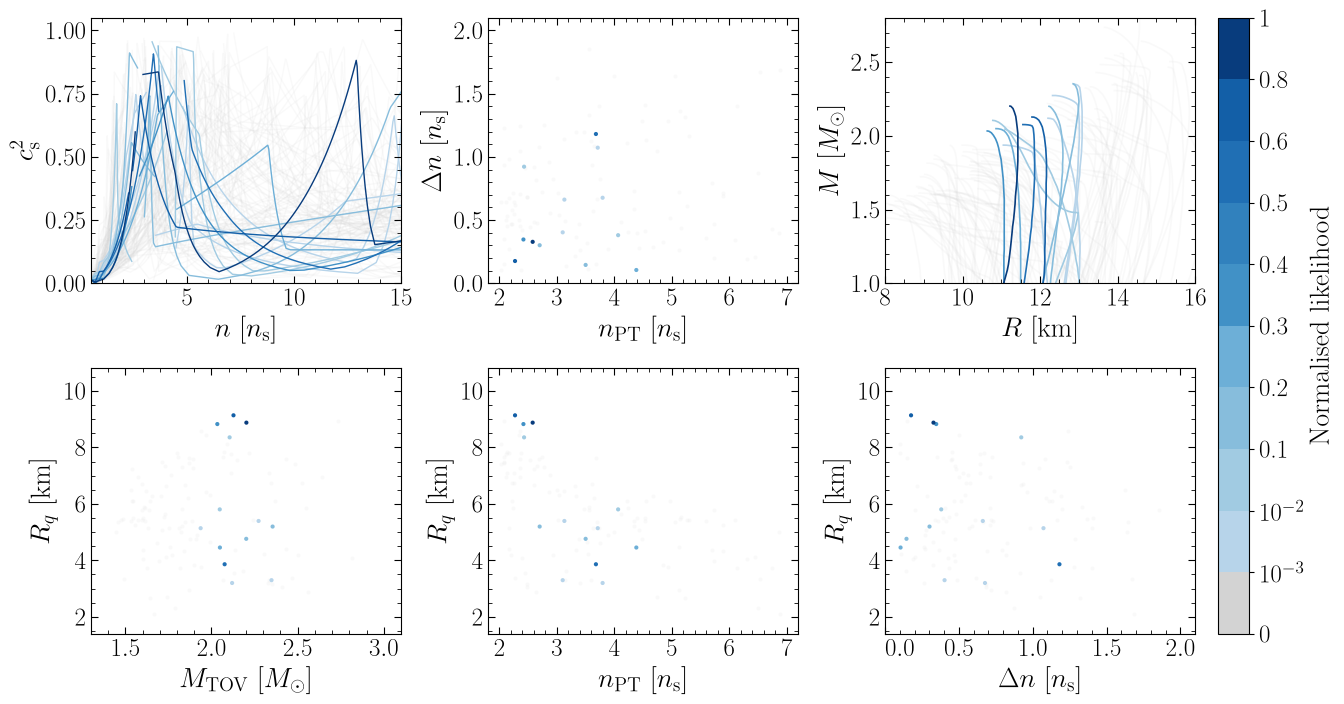

In [34]:
def qm_plot_results():

    fig, axs, cmap, bounds, norm = qm_setup_figure()

    threshold = bounds[1]
    faint = qm_normalized < threshold

    # Grey first, then the coloured models from the least to the most likely
    layers = (
        (np.where(faint)[0], "lightgrey", 0.12, 0),
        (np.where(~faint)[0][np.argsort(qm_normalized[~faint])], None, 1.0, 1),
    )

    for index, flat, alpha, zorder in layers:

        colors = flat if flat is not None else cmap(norm(qm_normalized[index]))

        # One polyline per side of the mixed phase for cs2, and one per stable
        # branch for M(R): a model contributes several segments either way, so
        # its colour has to be repeated across them.
        cs2_segments, cs2_colors = [], []
        mr_segments, mr_colors = [], []

        for position, k in enumerate(index):

            color = flat if flat is not None else colors[position]

            for segment in qm_single_phase_segments(
                qm_models["n"][k],
                qm_models["cs2"][k],
                qm_models["npt"][k],
                qm_models["dn"][k],
            ):
                cs2_segments.append(segment)
                cs2_colors.append(color)

            for branch in qm_models["mr"][k]:
                mr_segments.append(branch)
                mr_colors.append(color)

        for ax, segments, segment_colors, width in (
            (axs[0, 0], cs2_segments, cs2_colors, 1.0),
            (axs[0, 2], mr_segments, mr_colors, 1.2),
        ):
            ax.add_collection(
                LineCollection(
                    segments,
                    colors=segment_colors,
                    linewidths=width,
                    alpha=alpha,
                    zorder=zorder,
                    rasterized=True,
                ),
                autolim=False,
            )

        # The scatter panels
        for ax, x, y in (
            (axs[0, 1], qm_models["npt"], qm_models["dn"]),
            (axs[1, 0], qm_models["mtov"], qm_models["rqm"]),
            (axs[1, 1], qm_models["npt"], qm_models["rqm"]),
            (axs[1, 2], qm_models["dn"], qm_models["rqm"]),
        ):
            ax.scatter(
                x[index],
                y[index],
                s=QM_MARKER_SIZE,
                c=colors,
                marker=QM_MARKER,
                linewidths=0,
                alpha=alpha,
                zorder=zorder,
                rasterized=True,
            )

    print(f"number of plotted models: {faint.size:,}")
    print(f"below the first colour bound: {faint.sum():,}")

    save_figure(fig, "QMcoreEOSs.pdf")

    plt.show()


qm_plot_results()

## 4. `multiBand_crop.pdf` -- the two bands together

One point per model, twice over: the characteristic strain of the MHz
spectrum and the strain of the kHz quadrupole emission, coloured by the
normalized likelihood of the equation of state each model belongs to, with
the five sensitivity curves over them.

An equation of state is named by its group key in `results_0.h5`, which is the
id the sampler gave it.

In [35]:
use_style(**{
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 8,
    "figure.titlesize": 16,
})

mb_characteristic_frequency_parts = []
mb_characteristic_strain_parts = []
mb_quadrupole_frequency_parts = []
mb_quadrupole_strain_parts = []
mb_likelihood_parts = []

mb_number_of_eos = 0

for key, likelihood, data in gw_groups(("characteristic", "quadrupole")):

    characteristic = data["characteristic"]

    quadrupole = data["quadrupole"]

    number_of_models = characteristic.shape[1]

    # Row 0 holds the characteristic frequency,
    # row 1 the characteristic strain.
    mb_characteristic_frequency_parts.append(characteristic[0])
    mb_characteristic_strain_parts.append(characteristic[1])

    mb_quadrupole_frequency_parts.append(quadrupole[0])
    mb_quadrupole_strain_parts.append(quadrupole[1])

    mb_likelihood_parts.append(np.full(number_of_models, likelihood))

    mb_number_of_eos += 1

mb_characteristic_frequency = np.concatenate(mb_characteristic_frequency_parts)

mb_characteristic_strain = np.concatenate(mb_characteristic_strain_parts)

mb_quadrupole_frequency = np.concatenate(mb_quadrupole_frequency_parts)

mb_quadrupole_strain = np.concatenate(mb_quadrupole_strain_parts)

mb_likelihood = np.concatenate(mb_likelihood_parts)


# The file stores raw likelihoods only, and the scale they are put on is the
# one of the whole set: the largest likelihood of the accepted sample is the
# one that becomes 1. NaNs and small numerical excursions outside [0, 1] are
# removed along with it.
mb_likelihood_normalized = gw_normalize(mb_likelihood)

print(
    f"{mb_likelihood.size:,} models of {mb_number_of_eos:,} equations of "
    f"state, read from {RESULTS.name}"
)

9,616 models of 110 equations of state, read from results_0.h5


saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\multiBand_crop.pdf


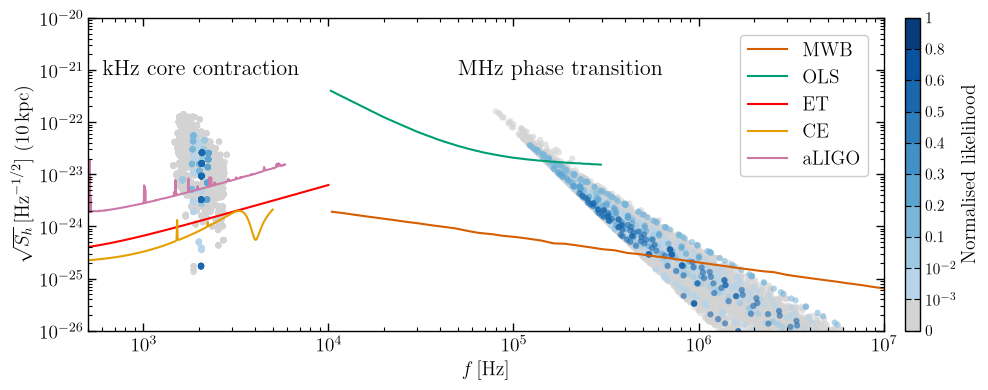

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))


# The color map and normalization must exist before plotting the ensemble
mb_cmap, mb_bounds, mb_norm, mb_cbar = add_likelihood_colorbar(
    fig,
    ax,
    fraction=0.025,
    pad=0.025,
    labelsize=11,
)


def mb_scatter_likelihood_colored(ax, frequency, strain, **kwargs):
    """
    Scatter one point per model, colored by its normalized likelihood.

    Only points that can be drawn on logarithmic axes are kept, and the
    lowest-likelihood points are drawn first so that the highest-likelihood
    ones remain visible on top.
    """
    finite_and_positive = (
        np.isfinite(frequency)
        & np.isfinite(strain)
        & (frequency > 0.0)
        & (strain > 0.0)
    )

    plot_order = np.argsort(mb_likelihood_normalized)

    plot_order = plot_order[finite_and_positive[plot_order]]

    options = {
        "s": 20,
        "marker": "o",
        "linewidths": 0.0,
        "alpha": 0.6,
        "rasterized": True,
        "zorder": 1.0,
    }

    options.update(kwargs)

    return ax.scatter(
        frequency[plot_order],
        strain[plot_order],
        c=mb_cmap(mb_norm(mb_likelihood_normalized[plot_order])),
        **options,
    )


ax.set_xscale("log")
ax.set_yscale("log")

mb_scatter_likelihood_colored(
    ax,
    mb_characteristic_frequency,
    mb_characteristic_strain,
)

mb_scatter_likelihood_colored(
    ax,
    mb_quadrupole_frequency,
    mb_quadrupole_strain,
)


# -----------------------------------------------------------------------------
# Detector sensitivity curves
# -----------------------------------------------------------------------------
mb_fmin = 1e4
mb_mask = mwbf >= mb_fmin

ax.loglog(
    mwbf[mb_mask],
    mwbstrain[mb_mask],
    color="#D55E00",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm MWB}$",
    zorder=10,
)

ax.loglog(
    levf,
    levstrain,
    color="#009E73",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm OLS}$",
    zorder=10,
)

ax.loglog(
    etf,
    etstrain,
    color="red",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm ET}$",
    zorder=10,
)

ax.loglog(
    cef,
    cestrain,
    color="#E69F00",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm CE}$",
    zorder=10,
)

ax.loglog(
    ligof,
    ligostrain,
    color="#CC79A7",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm aLIGO}$",
    zorder=10,
)

ax.text(6e2, 8e-22, r"${\rm kHz~core~contraction}$", fontsize=16)
ax.text(5e4, 8e-22, r"${\rm MHz~phase~transition}$", fontsize=16)


# -----------------------------------------------------------------------------
# Axis ranges, labels and ticks
# -----------------------------------------------------------------------------
ax.set_xlim(5.0e2, 1.0e7)
ax.set_ylim(1.0e-26, 1.0e-20)

ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
ax.set_ylabel(r"$\sqrt{S_h}\,[\mathrm{Hz}^{-1/2}]~(\mathrm{10\,kpc})$")

# Major labels at every decade, unlabeled minor ticks at 2, 3, ..., 9 within
# each decade, and the ticks, labels and frame above all the curves.
logarithmic_ticks(ax)


# -----------------------------------------------------------------------------
# Detector legend
# -----------------------------------------------------------------------------
mb_legend = ax.legend(
    loc="center",
    bbox_to_anchor=(0.90, 0.72),
    frameon=True,
    framealpha=1.0,
)

mb_legend.set_zorder(30)


plt.tight_layout()

save_figure(fig, "multiBand_crop.pdf")

plt.show()

## 5. `multiband_singleEOS.pdf` -- one equation of state

The same window as section 4, with the models of a single equation of state
in it: EOS 883, the one whose $p(e)$ curve is picked out in section 2 and
whose bubble scan is section 9. Every model of a group inherits the likelihood
of that group, so there is nothing left to colour the points by and they are
all black.

In [37]:
use_style(**{
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 8,
    "figure.titlesize": 16,
})

SE_KEY = "883"

se_likelihood, se_data = gw_group(SE_KEY, ("characteristic", "quadrupole"))

se_characteristic = se_data["characteristic"]

se_quadrupole = se_data["quadrupole"]

# Row 0 holds the frequency, row 1 the strain.
se_characteristic_frequency = se_characteristic[0]
se_characteristic_strain = se_characteristic[1]

se_quadrupole_frequency = se_quadrupole[0]
se_quadrupole_strain = se_quadrupole[1]

# The normalization is the one of section 4, so the number printed below can be
# read directly on its colorbar.
se_likelihood_normalized = float(gw_normalize(se_likelihood))

print(f"equation of state {SE_KEY}: {se_characteristic.shape[1]} models")

print(
    f"likelihood {se_likelihood:.3e}, "
    f"normalized {se_likelihood_normalized:.3f}"
)

equation of state 883: 78 models
likelihood 0.000e+00, normalized 0.000


saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\multiband_singleEOS.pdf


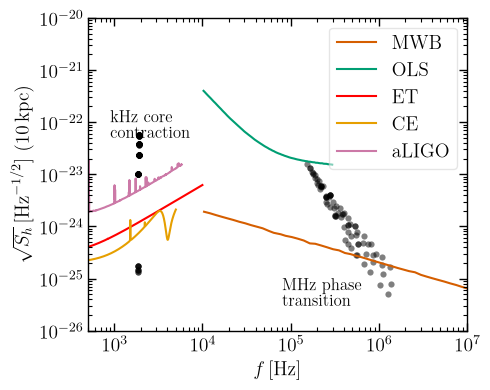

In [38]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.set_xscale("log")
ax.set_yscale("log")


# -----------------------------------------------------------------------------
# Detector sensitivity curves
# -----------------------------------------------------------------------------
se_mask = mwbf >= 1e4

ax.loglog(
    mwbf[se_mask],
    mwbstrain[se_mask],
    color="#D55E00",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm MWB}$",
    zorder=10,
)

ax.loglog(
    levf,
    levstrain,
    color="#009E73",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm OLS}$",
    zorder=10,
)

ax.loglog(
    etf,
    etstrain,
    color="red",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm ET}$",
    zorder=10,
)

ax.loglog(
    cef,
    cestrain,
    color="#E69F00",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm CE}$",
    zorder=10,
)

ax.loglog(
    ligof,
    ligostrain,
    color="#CC79A7",
    linestyle="-",
    linewidth=1.5,
    label=r"${\rm aLIGO}$",
    zorder=10,
)


# -----------------------------------------------------------------------------
# The two families of the chosen equation of state
# -----------------------------------------------------------------------------
def se_scatter_models(ax, frequency, strain, **kwargs):
    """
    Scatter one point per model.

    Only the points that can be drawn on logarithmic axes are kept.
    """
    finite_and_positive = (
        np.isfinite(frequency)
        & np.isfinite(strain)
        & (frequency > 0.0)
        & (strain > 0.0)
    )

    options = {
        "s": 20,
        "linewidths": 0.0,
        "alpha": 0.5,
        "rasterized": True,
        "zorder": 1.0,
    }

    options.update(kwargs)

    return ax.scatter(
        frequency[finite_and_positive],
        strain[finite_and_positive],
        **options,
    )


se_scatter_models(
    ax,
    se_quadrupole_frequency,
    se_quadrupole_strain,
    color="black",
    marker="o",
)

se_scatter_models(
    ax,
    se_characteristic_frequency,
    se_characteristic_strain,
    color="black",
    marker="o",
)


# -----------------------------------------------------------------------------
# Axis ranges and labels
# -----------------------------------------------------------------------------
# The window is the one of section 4, so that the two can be laid side by side.
# Some equations of state emit outside it; rather than dropping those points
# silently, they are counted below.
SE_FREQUENCY_LIMITS = (5.0e2, 1.0e7)

SE_STRAIN_LIMITS = (1.0e-26, 1.0e-20)

ax.set_xlim(*SE_FREQUENCY_LIMITS)
ax.set_ylim(*SE_STRAIN_LIMITS)

se_outside = 0

se_drawn = 0

for frequency, strain in (
    (se_characteristic_frequency, se_characteristic_strain),
    (se_quadrupole_frequency, se_quadrupole_strain),
):
    drawable = (
        np.isfinite(frequency)
        & np.isfinite(strain)
        & (frequency > 0.0)
        & (strain > 0.0)
    )

    within = (
        (frequency >= SE_FREQUENCY_LIMITS[0])
        & (frequency <= SE_FREQUENCY_LIMITS[1])
        & (strain >= SE_STRAIN_LIMITS[0])
        & (strain <= SE_STRAIN_LIMITS[1])
    )

    se_drawn += int(np.count_nonzero(drawable))

    se_outside += int(np.count_nonzero(drawable & ~within))

if se_outside:
    print(
        f"{se_outside} of the {se_drawn} points of equation of state "
        f"{SE_KEY} lie outside the plotted window; widen "
        "SE_FREQUENCY_LIMITS or SE_STRAIN_LIMITS to see them."
    )

ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
ax.set_ylabel(r"$\sqrt{S_h}\,[\mathrm{Hz}^{-1/2}]~(\mathrm{10\,kpc})$")

logarithmic_ticks(ax)


# -----------------------------------------------------------------------------
# Legend and the two names on the panel
# -----------------------------------------------------------------------------
se_legend = ax.legend(
    loc="upper right",
    ncol=1,
    frameon=True,
    framealpha=0.5,
    # the scattered points are small and half transparent, which is
    # unreadable at the size of a legend entry
    markerscale=2.0,
)

se_legend.set_zorder(30)

ax.text(9e2, 10.0e-23, r"${\rm kHz~core}$", fontsize=12)
ax.text(9e2, 5e-23, r"${\rm contraction}$", fontsize=12)
ax.text(8e4, 6e-26, r"${\rm MHz~phase}$", fontsize=12)
ax.text(8e4, 3e-26, r"${\rm transition}$", fontsize=12)


plt.tight_layout()

save_figure(fig, "multiband_singleEOS.pdf")

plt.show()

## 6. The frequency scalings

Three figures out of one reading of the set:

* `quadVsChar_ellipse.pdf` -- the kHz frequency against the average MHz
  characteristic frequency, one point per equation of state, with the two
  fits and the likelihood-weighted 95 per cent region.
* `peakVsChar.pdf` -- the peak frequency of the MHz spectrum against its
  characteristic one, one point per model, with the proportionality.
* `quadVsChar_conditioned.pdf` -- the first figure again, with a mock kHz
  measurement drawn on it and the region the ensemble has once that
  measurement has reweighted it.

How the many characteristic frequencies of one equation of state are
collapsed into a single number matters, so it is a choice made in the open.
The characteristic frequency is itself a logarithmic centroid of the spectrum
and within one equation of state it spreads over decades, so the geometric
mean is the most faithful of the three; the arithmetic mean is only the
plainest reading of the word "average".

In [39]:
use_style(**{
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "legend.title_fontsize": 8,
    "figure.titlesize": 16,
})

# "mean", "median" or "geometric"
FQ_AVERAGE = "geometric"

# The same choice for the quadrupole frequency. It hardly matters, since that
# frequency is nearly constant within an equation of state, but the spread is
# measured below rather than assumed away.
FQ_QUADRUPOLE_AVERAGE = FQ_AVERAGE

# Above this relative spread an equation of state is reported as one whose
# quadrupole frequency is not a single number.
FQ_QUADRUPOLE_TOLERANCE = 0.05

# How the slope alpha of y = alpha x is estimated:
#
#     "log"      geometric mean of the ratios y/x, that is the least-squares
#                fit in log space, where the data live
#     "median"   median of the ratios, insensitive to outliers
#     "lsq"      ordinary least squares through the origin; this weights each
#                point by x squared and is therefore set by the largest few
FQ_FIT_METHOD = "log"

# Every equation of state of the set is read; nothing is thresholded away.
FQ_LIKELIHOOD_THRESHOLD = 0.00


def fq_average(values, method=FQ_AVERAGE):
    """Collapse a set of frequencies into a single number.

    The values that cannot be averaged in log space, that is the non-finite
    and the non-positive ones, are dropped first, so that the three methods
    act on the same sample.
    """
    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values) & (values > 0.0)]

    if values.size == 0:
        return np.nan

    if method == "mean":
        return float(np.mean(values))

    if method == "median":
        return float(np.median(values))

    if method == "geometric":
        return float(np.exp(np.mean(np.log(values))))

    raise ValueError(
        f"Unknown averaging method {method!r}; use "
        "'mean', 'median', or 'geometric'."
    )


def fq_relative_spread(values):
    """Full range of a set of values, divided by their mean."""
    values = np.asarray(values, dtype=float)

    values = values[np.isfinite(values) & (values > 0.0)]

    if values.size == 0:
        return np.nan

    return float((values.max() - values.min()) / values.mean())

In [40]:
def fq_fit_relation(x, y, weights=None, method=FQ_FIT_METHOD):
    """Fit both forms of the relation between x and y to the same points.

        y = alpha x           the proportionality, one free parameter
        y = beta x**gamma     the power law, two free parameters

    Both are least squares in the logarithms, where the points live: the
    first holds the exponent at one and fits the offset, the second fits
    both. They are returned together because only their comparison tells
    whether the proportionality is a scaling or merely the ratio of two
    typical values, and the constant y = <y> is fitted beside them as the
    reference that any real dependence on x has to beat.

    Each squared residual is multiplied by the weight of its point.
    weights=None gives every point the weight one and reproduces the
    unweighted fit exactly, so the two readings differ in nothing but the
    weights. A point of zero weight is dropped, which is why a weighted fit
    reports fewer points: a good many likelihoods underflow to zero.

    Returned, besides the parameters themselves:

        alpha_factor   the multiplicative standard error of alpha
        beta_factor    the same for beta
        gamma_error    the standard error of gamma, which is additive
        pivot          the abscissa where the power law is best determined,
                       the weighted geometric mean of x
        correlation    the Pearson coefficient of ln y against ln x
        rms            the residuals of the three forms, in decades
        n_eff          the effective sample size, equal to n when unweighted
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    weights = (
        np.ones_like(x) if weights is None else np.asarray(weights, dtype=float)
    )

    usable = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(weights)
        & (x > 0.0)
        & (y > 0.0)
        & (weights > 0.0)
    )

    x = x[usable]
    y = y[usable]
    weights = weights[usable]

    if x.size < 3:
        raise ValueError(
            "Fewer than three usable points: the two-parameter fit has no "
            "degrees of freedom left."
        )

    # Normalized to sum to one, so that every sum below is an average and the
    # unweighted case is simply w = 1/n
    w = weights / np.sum(weights)

    n_eff = effective_size(weights)

    log_x = np.log(x)
    log_y = np.log(y)

    # -------------------------------------------------------------------------
    # y = alpha x
    # -------------------------------------------------------------------------
    ratio = y / x

    log_ratio = log_y - log_x

    if method == "log":
        alpha = float(np.exp(np.sum(w * log_ratio)))

    elif method == "median":
        alpha = float(weighted_quantile(ratio, 0.5, weights))

    elif method == "lsq":
        alpha = float(np.sum(w * x * y) / np.sum(w * x * x))

    else:
        raise ValueError(
            f"Unknown fitting method {method!r}; use "
            "'log', 'median', or 'lsq'."
        )

    spread_ratio = float(np.sum(w * (log_ratio - np.sum(w * log_ratio)) ** 2))

    # Standard error of the weighted mean of ln(y/x), as the multiplicative
    # uncertainty of alpha itself
    alpha_factor = float(
        np.exp(np.sqrt(spread_ratio * n_eff / (n_eff - 1.0)) / np.sqrt(n_eff))
    )

    # -------------------------------------------------------------------------
    # y = beta x**gamma
    # -------------------------------------------------------------------------
    mean_x = float(np.sum(w * log_x))
    mean_y = float(np.sum(w * log_y))

    dx = log_x - mean_x
    dy = log_y - mean_y

    spread_x = float(np.sum(w * dx * dx))

    gamma = float(np.sum(w * dx * dy) / spread_x)

    log_beta = mean_y - gamma * mean_x

    residual = log_y - (log_beta + gamma * log_x)

    # The textbook errors of a straight line fitted to the logarithms, with
    # the effective sample size in the place of the number of points
    variance = float(np.sum(w * residual**2) * n_eff / (n_eff - 2.0))

    gamma_error = float(np.sqrt(variance / spread_x / n_eff))

    log_beta_error = float(
        np.sqrt(variance * (1.0 / n_eff + mean_x**2 / (n_eff * spread_x)))
    )

    pivot = float(np.exp(mean_x))

    pivot_value = float(np.exp(log_beta + gamma * mean_x))

    pivot_factor = float(np.exp(np.sqrt(variance / n_eff)))

    # -------------------------------------------------------------------------
    # y = constant, and how well each of the three does
    # -------------------------------------------------------------------------
    constant = float(np.exp(mean_y))

    # The root mean square of the residuals, in decades. This comparison is
    # what settles whether a proportionality is a scaling or an accident:
    # one that does worse than a horizontal line has no x in it at all.
    def rms_residual(prediction):
        return float(np.sqrt(np.sum(w * np.log10(y / prediction) ** 2)))

    rms = {
        "proportional": rms_residual(alpha * x),
        "power law": rms_residual(np.exp(log_beta) * x**gamma),
        "constant": rms_residual(np.full_like(y, constant)),
    }

    return {
        "alpha": alpha,
        "alpha_factor": alpha_factor,
        "beta": float(np.exp(log_beta)),
        "beta_factor": float(np.exp(log_beta_error)),
        "gamma": float(gamma),
        "gamma_error": gamma_error,
        "pivot": pivot,
        "pivot_value": pivot_value,
        "pivot_factor": pivot_factor,
        "constant": constant,
        "correlation": float(
            np.sum(w * dx * dy) / np.sqrt(spread_x * np.sum(w * dy * dy))
        ),
        "rms": rms,
        "n": int(x.size),
        "n_eff": n_eff,
        "method": method,
    }


def fq_print_fit(title, fit, forms=("proportional", "power law", "constant")):
    """The fitted parameters, and how well each form describes the points.

    The forms are named as in the rms dictionary. Leaving one out is how a
    form that has been ruled out stops taking up room: the proportionality is
    dropped from the equation-of-state pairs, where it fits worse than a
    horizontal line, and kept for the models, where it is the right form.
    """
    print(title)
    print("-" * len(title))

    print("  points".ljust(26) + f"{fit['n']}")
    print("  effective points".ljust(26) + f"{fit['n_eff']:.1f}")
    print("  correlation of logs".ljust(26) + f"{fit['correlation']:.3f}")

    if "proportional" in forms:
        print(f"\n  y = alpha x        ({fit['method']})")
        print(
            "    alpha".ljust(26)
            + f"{fit['alpha']:.4g}"
            + f"   times or divided by {fit['alpha_factor']:.3f}"
        )
        print(
            "    rms residual".ljust(26)
            + f"{fit['rms']['proportional']:.3f} dex"
        )

    if "power law" in forms:
        print("\n  y = beta x^gamma")
        print(
            "    beta".ljust(26)
            + f"{fit['beta']:.4g}"
            + f"   times or divided by {fit['beta_factor']:.3f}"
        )
        print(
            "    gamma".ljust(26)
            + f"{fit['gamma']:.4f}"
            + f"   +/- {fit['gamma_error']:.4f}"
        )
        print(
            "    at the pivot".ljust(26)
            + f"{fit['pivot_value']:.4g}"
            + f"   at x = {fit['pivot']:.4g}"
        )
        print(
            "    rms residual".ljust(26)
            + f"{fit['rms']['power law']:.3f} dex"
        )

    if "constant" in forms:
        print("\n  y = constant")
        print("    constant".ljust(26) + f"{fit['constant']:.4g}")
        print(
            "    rms residual".ljust(26) + f"{fit['rms']['constant']:.3f} dex"
        )

    print()

In [41]:
# -----------------------------------------------------------------------------
# One pass over the set
# -----------------------------------------------------------------------------
# The group key in results_0.h5 is what names an equation of state.
fq_eos_labels = []

fq_quadrupole_frequency = []
fq_characteristic_average = []

fq_quadrupole_relative_spread = []

fq_eos_likelihood = []

# Kept whole, for the model-by-model comparison of peakVsChar
fq_peak_parts = []
fq_characteristic_parts = []
fq_model_likelihood_parts = []

fq_number_of_eos = 0

for key, likelihood, data in gw_groups(("quadrupole", "characteristic", "peaks")):

    fq_number_of_eos += 1

    quadrupole = data["quadrupole"]
    characteristic = data["characteristic"]
    peaks = data["peaks"]

    number_of_models = characteristic.shape[1]

    if likelihood / MAX_LIKELIHOOD < FQ_LIKELIHOOD_THRESHOLD:
        continue

    fq_eos_labels.append(key)

    fq_quadrupole_frequency.append(
        fq_average(quadrupole[0], method=FQ_QUADRUPOLE_AVERAGE)
    )

    fq_characteristic_average.append(
        fq_average(characteristic[0], method=FQ_AVERAGE)
    )

    fq_quadrupole_relative_spread.append(fq_relative_spread(quadrupole[0]))

    fq_eos_likelihood.append(likelihood)

    fq_peak_parts.append(peaks[0])
    fq_characteristic_parts.append(characteristic[0])

    fq_model_likelihood_parts.append(
        np.full(number_of_models, likelihood)
    )

fq_quadrupole_frequency = np.array(fq_quadrupole_frequency)
fq_characteristic_average = np.array(fq_characteristic_average)
fq_quadrupole_relative_spread = np.array(fq_quadrupole_relative_spread)

fq_eos_likelihood = np.array(fq_eos_likelihood)

# Normalized as in section 4, so that the colours of the figures mean the same
fq_eos_likelihood_normalized = gw_normalize(fq_eos_likelihood)

# One point per model, for peakVsChar
fq_peak_frequency = np.concatenate(fq_peak_parts)
fq_characteristic_frequency = np.concatenate(fq_characteristic_parts)

fq_model_likelihood_normalized = gw_normalize(
    np.concatenate(fq_model_likelihood_parts)
)

print(f"{len(fq_eos_labels)} equations of state, {fq_peak_frequency.size:,} models")

print(f"characteristic frequency averaged with the {FQ_AVERAGE}")

# The quadrupole frequency is taken to be one number per equation of state.
# It is not exactly one, so here is by how much it is not.
print(
    "spread of the quadrupole frequency within one equation of state: "
    f"median {np.nanmedian(fq_quadrupole_relative_spread):.3f}, "
    f"largest {np.nanmax(fq_quadrupole_relative_spread):.3f}"
)

fq_exceeding = int(
    np.count_nonzero(fq_quadrupole_relative_spread > FQ_QUADRUPOLE_TOLERANCE)
)

print(
    f"{fq_exceeding} of the {len(fq_eos_labels)} equations of state spread by "
    f"more than {100.0 * FQ_QUADRUPOLE_TOLERANCE:.0f} per cent, so for all the "
    "others the single-value reading holds to better than that"
)

110 equations of state, 9,616 models
characteristic frequency averaged with the geometric
spread of the quadrupole frequency within one equation of state: median 0.026, largest 0.147
20 of the 110 equations of state spread by more than 5 per cent, so for all the others the single-value reading holds to better than that


In [42]:
# -----------------------------------------------------------------------------
# The fits
# -----------------------------------------------------------------------------
# For the equation-of-state pairs the proportionality y = alpha x is left out
# of the report: it fits those points worse than a horizontal line does, so its
# alpha is not a scaling between the two frequencies but only the ratio of
# their typical values. What is fitted there is the power law, against the
# constant that any real dependence on x has to beat.
#
# For the models the proportionality is the right form, and it is the one line
# the figure draws.
fq_eos_fit = fq_fit_relation(
    fq_characteristic_average,
    fq_quadrupole_frequency,
    method=FQ_FIT_METHOD,
)

fq_eos_fit_weighted = fq_fit_relation(
    fq_characteristic_average,
    fq_quadrupole_frequency,
    weights=fq_eos_likelihood_normalized,
    method=FQ_FIT_METHOD,
)

fq_print_fit(
    "f_ch,k against <f_ch,M>, one point per equation of state",
    fq_eos_fit,
    forms=("power law", "constant"),
)

fq_print_fit(
    "the same, weighted by the likelihood",
    fq_eos_fit_weighted,
    forms=("power law", "constant"),
)


fq_model_fit = fq_fit_relation(
    fq_characteristic_frequency,
    fq_peak_frequency,
    method=FQ_FIT_METHOD,
)

fq_model_fit_weighted = fq_fit_relation(
    fq_characteristic_frequency,
    fq_peak_frequency,
    weights=fq_model_likelihood_normalized,
    method=FQ_FIT_METHOD,
)

fq_print_fit(
    "f_peak,M against f_ch,M, one point per model",
    fq_model_fit,
)

fq_print_fit(
    "the same, weighted by the likelihood",
    fq_model_fit_weighted,
)

f_ch,k against <f_ch,M>, one point per equation of state
--------------------------------------------------------
  points                  110
  effective points        110.0
  correlation of logs     0.117

  y = beta x^gamma
    beta                  1363   times or divided by 1.353
    gamma                 0.0280   +/- 0.0228
    at the pivot          1974   at x = 5.596e+05
    rms residual          0.070 dex

  y = constant
    constant              1974
    rms residual          0.071 dex

the same, weighted by the likelihood
------------------------------------
  points                  59
  effective points        3.0
  correlation of logs     -0.335

  y = beta x^gamma
    beta                  3609   times or divided by 4.667
    gamma                 -0.0423   +/- 0.1163
    at the pivot          2064   at x = 5.581e+05
    rms residual          0.026 dex

  y = constant
    constant              2064
    rms residual          0.027 dex

f_peak,M against f_ch,M, one point 

In [43]:
# -----------------------------------------------------------------------------
# Figure machinery
# -----------------------------------------------------------------------------
# The confidence ellipse wants the chi-square quantile. For two degrees of
# freedom the chi-square distribution is an exponential, so that number is
# exact in closed form and scipy is not needed for it:
#
#     chi2.ppf(p, df=2) = -2 ln(1 - p),   which is 5.991464547 at 95%
#
# This matters here because the environment has no scipy installed.

# -----------------------------------------------------------------------------
# The windows
# -----------------------------------------------------------------------------
# Nothing computes these: they are the windows of the figures, in hertz, and
# the only thing that sets them. A point outside the window is not drawn, and
# the count of them is printed under the figure.

# The mock kHz measurement of the conditioning section, and the region the
# ensemble has once that measurement has reweighted it. Orange: not blue,
# which the likelihood colour scale of the points has taken, and not red,
# which is the posterior fit.
FQ_MEASUREMENT_COLOUR = "orange"

FQ_CONDITIONED_COLOUR = "orange"

# quadVsChar_ellipse and quadVsChar_conditioned: <f_ch,M> across, f_ch,k up
FQ_X_LIMITS = (4.0e4, 2.0e7)

FQ_Y_LIMITS = (1.2e3, 3.1e3)

# peakVsChar: both axes carry the same quantity and share one window, so that
# the fitted line keeps the angle its slope deserves
FQ_MODEL_LIMITS = (2.0e4, 2.0e8)


def fq_grid(low, high, points=200):
    """
    The abscissae a fitted curve is drawn on.

    Two of them are enough for a power law on logarithmic axes, where it is a
    straight line, and are wrong on linear axes, where it is not: over the
    range of the first figure the chord between the two ends misses the curve
    by some eight per cent. A straight line is still drawn from its two ends.
    """
    low = max(low, high * 1.0e-6)

    return np.logspace(np.log10(low), np.log10(high), points)


def fq_style_ticks(ax, scaling):
    """The ticks of the multi-band figure, on either scaling."""
    if scaling == "log":
        logarithmic_ticks(ax)

    elif scaling == "linear":
        linear_ticks(ax)

    else:
        raise ValueError(f"scaling is {scaling!r}; use 'log' or 'linear'.")


def fq_hertz_ticks(ax):
    """
    Label the vertical axis in hertz, on a round step.

    The kHz frequencies cover a fraction of a decade, so on a logarithmic
    axis the decade labels alone would leave it blank. The step is the
    smallest round one that keeps the labels few; the ticks outside the
    window are simply not drawn.
    """
    low, high = ax.get_ylim()

    for step in (50.0, 100.0, 200.0, 250.0, 500.0, 1000.0, 2000.0):
        if (high - low) / step <= 6.0:
            break

    labelled = np.arange(0.0, 20001.0, step)

    ax.yaxis.set_major_locator(FixedLocator(labelled))

    ax.yaxis.set_major_formatter(
        FixedFormatter([f"{value:.0f}" for value in labelled])
    )

    ax.yaxis.set_minor_locator(
        FixedLocator(np.arange(0.0, 20001.0, 0.5 * step))
    )

    ax.yaxis.set_minor_formatter(NullFormatter())

    # Those locators build new ticks, which start again underneath the data
    raise_axis_decorations(ax, zorder=20)


def fq_likelihood_ellipse(x, y, weights, confidence=0.95, points=500):
    """
    The confidence ellipse of a weighted set of points, built in log10 space.

    The points spread over decades in x and over a factor in y, so the
    covariance is taken between their logarithms and the curve is mapped back
    to frequencies afterwards.

    The weights are the normalized likelihoods, so this centre is the
    likelihood-weighted one, while the fits weight every equation of state
    alike: the cross and the dashed line need not meet.
    """
    usable = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(weights)
        & (x > 0.0)
        & (y > 0.0)
        & (weights > 0.0)
    )

    log_x = np.log10(x[usable])
    log_y = np.log10(y[usable])

    weight = weights[usable] / np.sum(weights[usable])

    centre_x = float(np.sum(weight * log_x))
    centre_y = float(np.sum(weight * log_y))

    dx = log_x - centre_x
    dy = log_y - centre_y

    covariance = np.array([
        [np.sum(weight * dx * dx), np.sum(weight * dx * dy)],
        [np.sum(weight * dx * dy), np.sum(weight * dy * dy)],
    ])

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.linspace(0.0, 2.0 * np.pi, points)

    curve = (
        np.array([[centre_x], [centre_y]])
        + eigenvectors
        @ np.diag(np.sqrt(eigenvalues * (-2.0 * np.log(1.0 - confidence))))
        @ np.vstack((np.cos(angle), np.sin(angle)))
    )

    return (
        10.0**curve[0],
        10.0**curve[1],
        10.0**centre_x,
        10.0**centre_y,
    )

In [44]:
def fq_plot_eos_pairs(
    x_limits=FQ_X_LIMITS,
    y_limits=FQ_Y_LIMITS,
    scaling="log",
    ellipse=False,
    power_law=True,
    measurement=None,
    credible=0.95,
    save=None,
):
    """
    The kHz frequency against the average MHz characteristic frequency.

    The dotted line is the fit y = beta x^gamma, straight on these logarithmic
    axes with the exponent for its slope. The proportionality y = alpha x is
    not drawn: it would have to climb a decade in y for every decade in x,
    which these points do not do, and it fits them worse than a horizontal
    line. scaling="linear" draws the figure on linear axes, where the power law
    becomes the curved one.

    measurement is a result of fq_condition(). It adds the shaded horizontal
    band of the mock kHz measurement and, with ellipse=True, a second credible
    region: the region the ensemble has once that measurement has reweighted
    it. The black region is then what the measurement starts from, so the pair
    is the whole of the update, drawn. Only the measurement is shaded;
    everything that is inferred is a line.
    """
    fig, ax = plt.subplots(figsize=(5, 4))

    cmap, bounds, norm, cbar = add_likelihood_colorbar(
        fig,
        ax,
        fraction=0.05,
        pad=0.03,
        labelsize=11,
    )

    ax.set_xscale(scaling)
    ax.set_yscale(scaling)

    # Least likely first, so that the likely equations of state stay on top
    plot_order = np.argsort(fq_eos_likelihood_normalized)

    ax.scatter(
        fq_characteristic_average[plot_order],
        fq_quadrupole_frequency[plot_order],
        c=cmap(norm(fq_eos_likelihood_normalized[plot_order])),
        s=100,
        marker="o",
        linewidths=0.0,
        alpha=0.6,
        rasterized=True,
        zorder=1.0,
    )

    # A credible region reaches past the points it is built from, so the
    # window has to be wide enough to hold it or it is drawn as two arcs
    # leaving the frame.
    #
    # With a measurement given there are two of them: the region as it stands,
    # which is what the measurement starts from, and the region the same
    # ensemble has once the measurement has reweighted it. The second is what
    # the kHz measurement is worth, drawn rather than tabulated.
    if ellipse:
        percentage = f"{100.0 * credible:.0f}"

        regions = [
            (
                fq_eos_likelihood_normalized,
                "black",
                rf"${percentage}\%~{{\rm informed}}$"
                if measurement is not None
                else "_nolegend_",
            )
        ]

        if measurement is not None:
            regions.append(
                (
                    measurement["weights"],
                    FQ_CONDITIONED_COLOUR,
                    rf"${percentage}\%~{{\rm conditioned}}$",
                )
            )

        regions = [
            (
                fq_likelihood_ellipse(
                    fq_characteristic_average,
                    fq_quadrupole_frequency,
                    weights,
                    confidence=credible,
                ),
                colour,
                label,
            )
            for weights, colour, label in regions
        ]

    # The fit, curved on linear axes and so drawn point by point. Both
    # readings are drawn, the unweighted one grey and dotted and the
    # likelihood-weighted one red and dashed. The unweighted fit is the prior,
    # every equation of state counting alike; weighting by the likelihood is
    # what makes it the posterior.
    if power_law:
        grid = fq_grid(*x_limits)

        for fit, colour, dashes, name in (
            (fq_eos_fit_weighted, POSTERIOR_COLOUR, "--", "informed"),
            (fq_eos_fit, PRIOR_COLOUR, ":", "uninformed"),
        ):
            if measurement is not None:
                name = f"{name}~fit"

            ax.plot(
                grid,
                fit["beta"] * grid**fit["gamma"],
                color=colour,
                linestyle=dashes,
                linewidth=1.5,
                zorder=15,
                label=rf"${{\rm {name}}}$",
            )

    if ellipse:
        for (
            (ellipse_x, ellipse_y, centre_x, centre_y),
            colour,
            label,
        ) in regions:
            ax.plot(
                ellipse_x,
                ellipse_y,
                color=colour,
                linestyle="-",
                linewidth=1.8,
                zorder=12,
                label=label,
            )

            ax.scatter(
                centre_x,
                centre_y,
                marker="x",
                s=45,
                linewidths=1.5,
                color=colour,
                zorder=13,
            )

        # What the ellipse is, written beside it rather than in the legend,
        # which already carries the two fits. The anchor is the upper tip of
        # the major axis, so the label follows the ellipse wherever the
        # likelihood puts it instead of sitting at a fixed corner. With two
        # regions drawn there is one to tell from the other, so the legend
        # names them both and this is left off.
        if measurement is None:
            ellipse_x, ellipse_y = regions[0][0][0], regions[0][0][1]

            tip = int(np.argmax(ellipse_x))

            ax.text(
                0.4 * ellipse_x[tip],
                1.1 * ellipse_y[tip],
                rf"${percentage}\%$",
                color="black",
                fontsize=13,
                ha="left",
                va="bottom",
                zorder=14,
            )

    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)

    if measurement is not None:
        ax.axhspan(
            measurement["band"][0],
            measurement["band"][1],
            color=FQ_MEASUREMENT_COLOUR,
            alpha=0.40,
            linewidth=0.0,
            zorder=0.3,
            label=(
                r"$f_{\rm ch,k}^{\rm obs} = "
                + f"{measurement['observed']:.0f}"
                + r" \pm "
                + f"{measurement['precision'] * measurement['observed']:.0f}"
                + r"~{\rm Hz}$"
            ),
        )

    ax.set_xlabel(r"$\langle f_{\mathrm{ch,M}}\rangle\, [\mathrm{Hz}]$")

    ax.set_ylabel(r"$f_{\rm{ch,k}}\, [\mathrm{Hz}]$")

    fq_style_ticks(ax, scaling)

    if scaling == "log":
        fq_hertz_ticks(ax)

    report_outside(
        ax,
        fq_characteristic_average,
        fq_quadrupole_frequency,
        "equations of state",
    )

    # Nothing but the points is drawn when both the fit and the ellipse are
    # turned off, and an empty legend is an empty box
    if ax.get_legend_handles_labels()[0]:
        legend = ax.legend(
            loc="lower right",
            frameon=True,
            framealpha=0.8,
            fontsize=None if measurement is None else 9,
        )

        legend.set_zorder(30)

    fig.tight_layout()

    if save is not None:
        save_figure(fig, save)

    plt.show()


def fq_plot_model_pairs(limits=FQ_MODEL_LIMITS, scaling="log", power_law=False, save=None):
    """
    The peak frequency of the MHz spectrum against its characteristic one.

    Both axes carry the same quantity, so they share the one window given in
    limits, in hertz, and an equal aspect, and the fitted line keeps the angle
    its slope deserves.

    Here the proportionality is the right form, so it is the only line drawn;
    power_law=True adds the two-parameter fit, which for these points is all
    but the same line.
    """
    fig, ax = plt.subplots(figsize=(5, 4))

    cmap, bounds, norm, cbar = add_likelihood_colorbar(
        fig,
        ax,
        fraction=0.05,
        pad=0.03,
        labelsize=11,
    )

    ax.set_xscale(scaling)
    ax.set_yscale(scaling)

    drawable = (
        np.isfinite(fq_characteristic_frequency)
        & np.isfinite(fq_peak_frequency)
        & (fq_characteristic_frequency > 0.0)
        & (fq_peak_frequency > 0.0)
    )

    plot_order = np.argsort(fq_model_likelihood_normalized)

    plot_order = plot_order[drawable[plot_order]]

    ax.scatter(
        fq_characteristic_frequency[plot_order],
        fq_peak_frequency[plot_order],
        c=cmap(norm(fq_model_likelihood_normalized[plot_order])),
        s=100,
        marker="o",
        linewidths=0.0,
        alpha=0.6,
        rasterized=True,
        zorder=1.0,
    )

    edges = np.array(limits, dtype=float)

    # Only the weighted fit is drawn here. The unweighted one is 0.8455 against
    # 0.8377 and the two lines cannot be told apart on these axes.
    ax.plot(
        edges,
        fq_model_fit_weighted["alpha"] * edges,
        color="red",
        linestyle="--",
        linewidth=1.5,
        zorder=15,
        label=(
            r"$f_{\rm max,M} = "
            + f"{fq_model_fit_weighted['alpha']:.3f}"
            + r"\,f_{\rm ch,M}$"
        ),
    )

    if power_law:
        grid = fq_grid(*limits)

        ax.plot(
            grid,
            fq_model_fit_weighted["beta"] * grid**fq_model_fit_weighted["gamma"],
            color="red",
            linestyle="--",
            linewidth=1.5,
            zorder=15,
            label=(
                r"$f_{\rm max,M} = "
                + f"{fq_model_fit_weighted['beta']:.3g}"
                + r"\,f_{\rm ch,M}^{"
                + f"{fq_model_fit_weighted['gamma']:.3f}"
                + r"}$"
            ),
        )

    ax.set_xlim(*limits)
    ax.set_ylim(*limits)

    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"$f_{\rm ch,M}\,[\mathrm{Hz}]$")
    ax.set_ylabel(r"$f_{\rm max,M}\,[\mathrm{Hz}]$")

    fq_style_ticks(ax, scaling)

    report_outside(
        ax,
        fq_characteristic_frequency,
        fq_peak_frequency,
        "models",
    )

    legend = ax.legend(loc="upper left", frameon=True, framealpha=0.8)

    legend.set_zorder(30)

    fig.tight_layout()

    if save is not None:
        save_figure(fig, save)

    plt.show()

### `quadVsChar_ellipse.pdf`

The ellipse is built from the covariance of the logarithms, so it is an
ellipse on these axes; its cross is the likelihood-weighted centre, while the
fit weights every equation of state alike.

saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\quadVsChar_ellipse.pdf


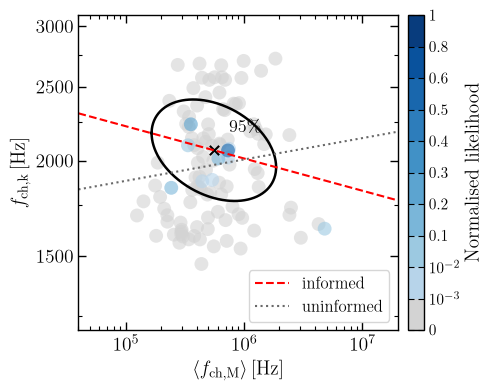

In [45]:
fq_plot_eos_pairs(
    ellipse=True,
    save="quadVsChar_ellipse.pdf",
)

### `peakVsChar.pdf`

Only the proportionality is drawn. Here it is the right form, so the
two-parameter fit would lie on top of it.

8 of the 9616 models lie outside the plotted window; widen the limits above to see them
saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\peakVsChar.pdf


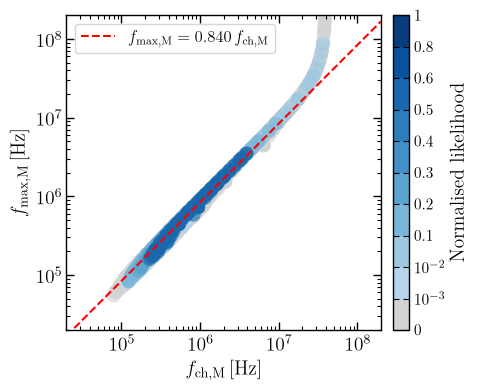

In [46]:
fq_plot_model_pairs(
    save="peakVsChar.pdf",
)

### `quadVsChar_conditioned.pdf`

Everything above measures the correlation between the two bands. This asks
what the correlation is worth: if the kHz characteristic frequency were
measured, by how much would the MHz prediction narrow?

The answer is one application of Bayes' theorem to the equation-of-state
ensemble and nothing else. No spectrum, no bubble and no fit is recomputed: a
mock kHz measurement gives each equation of state a likelihood, that
likelihood multiplies the weight the equation of state already carries, and
the same $\langle f_{\rm ch,M}\rangle$ values as above are read again under
the new weights.

The test is made one point per equation of state, because that is what the
claim is about: the kHz signal is said to reduce the *equation-of-state*
uncertainty in the MHz prediction, and averaging over the phase-conversion
parameters within each equation of state first is what leaves only that.

In [47]:
# The current posterior over equations of state: the same normalized likelihood
# that colours the figures, rescaled to sum to one so that it can be read as a
# probability. gw_normalize divides by the largest likelihood of the set, which
# is what a colour scale wants and not what a weight wants.
fq_conditioning_usable = (
    np.isfinite(fq_quadrupole_frequency)
    & np.isfinite(fq_characteristic_average)
    & (fq_quadrupole_frequency > 0.0)
    & (fq_characteristic_average > 0.0)
)

fq_posterior_weight = np.where(
    fq_conditioning_usable, fq_eos_likelihood_normalized, 0.0
)

fq_posterior_weight = fq_posterior_weight / fq_posterior_weight.sum()


def fq_kHz_likelihood(frequency, observed, precision, shape="lognormal"):
    """The likelihood of a mock kHz measurement, one value per equation of state.

    precision is the fractional one-sigma uncertainty of the measurement, so
    0.05 is a five per cent measurement.

        "lognormal"   Gaussian in ln f, of width ln(1 + precision). The
                      observable is positive and the figures are logarithmic,
                      so this is the natural form.
        "gaussian"    Gaussian in f itself, of width precision times observed.

    At five per cent the two are the same likelihood to a fraction of a per
    cent; the second is kept only so that the choice can be shown not to matter.
    """
    frequency = np.asarray(frequency, dtype=float)

    if shape == "lognormal":
        width = np.log1p(precision)

        residual = (np.log(frequency) - np.log(observed)) / width

    elif shape == "gaussian":
        width = precision * observed

        residual = (frequency - observed) / width

    else:
        raise ValueError(f"shape is {shape!r}; use 'lognormal' or 'gaussian'.")

    return np.exp(-0.5 * residual**2)


def fq_credible_interval(values, weights, credible=0.90):
    """The central credible interval of a weighted sample, in log10 space.

    The MHz frequency spans orders of magnitude, so the interval is quoted by
    its two ends in hertz and its width in decades: a width here is a factor
    and not a number of hertz, and only in the logarithm is it a length that
    can be compared before and after an update.

    The standard deviation of the logarithm is returned beside it. The two need
    not move together: the width of the interval is set by the tails of the
    distribution and the standard deviation by its body.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    usable = (
        np.isfinite(values)
        & (values > 0.0)
        & np.isfinite(weights)
        & (weights > 0.0)
    )

    logarithm = np.log10(values[usable])

    weight = weights[usable]

    tail = 0.5 * (1.0 - credible)

    low, median, high = weighted_quantile(
        logarithm, [tail, 0.5, 1.0 - tail], weight
    )

    mean = float(np.sum(weight * logarithm) / np.sum(weight))

    deviation = float(
        np.sqrt(np.sum(weight * (logarithm - mean) ** 2) / np.sum(weight))
    )

    return {
        "low": float(10.0**low),
        "median": float(10.0**median),
        "high": float(10.0**high),
        "width": float(high - low),
        "deviation": deviation,
        "mean": float(10.0**mean),
        "n_eff": effective_size(weight),
        "credible": credible,
    }


def fq_condition(
    precision,
    observed=None,
    centre="mean",
    shape="lognormal",
    credible=0.90,
    weights=None,
):
    """The whole update, as one dictionary.

    The mock measurement is put where the ensemble already expects it rather
    than where it would do the most good: centre="mean" puts it at the weighted
    mean of f_ch,k, "median" at the weighted median, and a number between zero
    and one at that quantile of the current kHz posterior. An explicit observed
    overrides all three.

    Returned: the baseline and conditioned intervals of <f_ch,M>, the reduction
    of the width of the interval and of the standard deviation, and the shift
    of the median. The last two are there because an update can select a part
    of the MHz range without narrowing it, and then the honest description is a
    shift and not a measurement.
    """
    weights = fq_posterior_weight if weights is None else weights

    weights = weights / weights.sum()

    if observed is None:
        if centre == "mean":
            observed = float(np.sum(weights * fq_quadrupole_frequency))

        elif centre == "median":
            observed = float(
                weighted_quantile(fq_quadrupole_frequency, 0.5, weights)
            )

        else:
            observed = float(
                weighted_quantile(
                    fq_quadrupole_frequency, float(centre), weights
                )
            )

    updated = weights * fq_kHz_likelihood(
        fq_quadrupole_frequency, observed, precision, shape=shape
    )

    updated = updated / updated.sum()

    baseline = fq_credible_interval(
        fq_characteristic_average, weights, credible=credible
    )

    conditioned = fq_credible_interval(
        fq_characteristic_average, updated, credible=credible
    )

    return {
        "observed": float(observed),
        "precision": float(precision),
        "shape": shape,
        "band": (
            float(observed) * (1.0 - precision),
            float(observed) * (1.0 + precision),
        ),
        "weights": updated,
        "baseline": baseline,
        "conditioned": conditioned,
        "reduction": 1.0 - conditioned["width"] / baseline["width"],
        "deviation_reduction": (
            1.0 - conditioned["deviation"] / baseline["deviation"]
        ),
        "shift": float(np.log10(conditioned["median"] / baseline["median"])),
    }


def fq_print_conditioning(title, result):
    """The two intervals, and what separates them."""
    print(title)
    print("-" * len(title))

    print(
        "  mock measurement".ljust(30)
        + f"{result['observed']:.6g} Hz"
        + f"   +/- {100.0 * result['precision']:.0f} per cent, that is "
        + f"{result['band'][0]:.6g} to {result['band'][1]:.6g} Hz"
    )

    for name, interval in (
        ("current", result["baseline"]),
        ("conditioned", result["conditioned"]),
    ):
        print(f"\n  <f_ch,M>, {name}")

        print(
            f"    {100.0 * interval['credible']:.0f} per cent interval".ljust(30)
            + f"{interval['low']:.6g} to {interval['high']:.6g} Hz"
        )

        print(
            "    width".ljust(30)
            + f"{interval['width']:.4f} dex"
            + f"   a factor {10.0 ** interval['width']:.2f}"
        )

        print("    median".ljust(30) + f"{interval['median']:.6g} Hz")

        print("    sd of log10".ljust(30) + f"{interval['deviation']:.4f} dex")

        print("    effective points".ljust(30) + f"{interval['n_eff']:.0f}")

    print(
        "\n  reduction of the width".ljust(31)
        + f"{100.0 * result['reduction']:.1f} per cent"
    )

    print(
        "  reduction of the sd".ljust(30)
        + f"{100.0 * result['deviation_reduction']:.1f} per cent"
    )

    print(
        "  shift of the median".ljust(30)
        + f"{result['shift']:+.3f} dex"
        + f"   a factor {10.0 ** result['shift']:.2f}"
    )

    print()

In [48]:
# =============================================================================
# The three knobs of the conditioning. Everything below follows from them: the
# intervals printed, the two ellipses and the legend that names them, and the
# band that draws the measurement.
# =============================================================================

# The fractional uncertainty of the mock kHz measurement
FQ_PRECISION = 0.05

# The credible level quoted in this subsection, figures included.
# quadVsChar_ellipse.pdf above is drawn at 95 per cent by the default of
# fq_plot_eos_pairs and is not affected by this.
FQ_CREDIBLE = 0.95

# The measured value the figure draws. Not the centred case of the headline
# below, which is the right number to quote but the wrong one to draw: a
# measurement at the centre of the posterior moves nothing, so the figure would
# show two regions lying on top of one another and say nothing about what a
# measurement is worth. Somewhere in the wings of the current f_ch,k posterior
# is what shows the update; the effective sample size printed below is the
# number to watch, since far into a tail the reweighted ensemble becomes too
# thin to say anything with.
FQ_ILLUSTRATIVE = 2300.0


# The headline: a five per cent measurement at the centre of the posterior,
# which is the one choice that cannot be accused of having been picked for the
# answer it gives. Its four numbers are the A, B, C, D of the draft paragraph
# and the reduction is its X.
fq_headline = fq_condition(FQ_PRECISION, centre="mean", credible=FQ_CREDIBLE)

fq_print_conditioning(
    f"<f_ch,M> conditioned on a {100.0 * FQ_PRECISION:.0f} per cent "
    "measurement of f_ch,k",
    fq_headline,
)


# The measurement the figure draws. The likelihood is the Gaussian one here
# rather than the log-normal default, so that the figure means exactly what its
# legend says: a log-normal of width ln(1 + PRECISION) is the measured value
# multiplied and divided by 1.05, which is not that value plus or minus five
# per cent of it. The two differ in the third digit of everything below.
fq_illustrative = fq_condition(
    FQ_PRECISION,
    observed=FQ_ILLUSTRATIVE,
    credible=FQ_CREDIBLE,
    shape="gaussian",
)

fq_print_conditioning(
    f"the measurement drawn in the figure: {FQ_ILLUSTRATIVE:.0f} Hz to "
    f"{100.0 * FQ_PRECISION:.0f} per cent",
    fq_illustrative,
)

# Where it sits in the current kHz posterior
fq_kHz_order = np.argsort(fq_quadrupole_frequency)

fq_kHz_cumulative = np.cumsum(fq_posterior_weight[fq_kHz_order])

fq_kHz_cumulative = fq_kHz_cumulative / fq_kHz_cumulative[-1]

print(
    "  it sits at the "
    + f"{100.0 * float(np.interp(FQ_ILLUSTRATIVE, fq_quadrupole_frequency[fq_kHz_order], fq_kHz_cumulative)):.0f}"
    + "th percentile of the current f_ch,k posterior\n"
)

<f_ch,M> conditioned on a 5 per cent measurement of f_ch,k
----------------------------------------------------------
  mock measurement            2067.45 Hz   +/- 5 per cent, that is 1964.08 to 2170.83 Hz

  <f_ch,M>, current
    95 per cent interval      235381 to 739436 Hz
    width                     0.4971 dex   a factor 3.14
    median                    731946 Hz
    sd of log10               0.2149 dex
    effective points          3

  <f_ch,M>, conditioned
    95 per cent interval      353215 to 739212 Hz
    width                     0.3207 dex   a factor 2.09
    median                    733679 Hz
    sd of log10               0.1083 dex
    effective points          2

  reduction of the width      35.5 per cent
  reduction of the sd         49.6 per cent
  shift of the median         +0.001 dex   a factor 1.00

the measurement drawn in the figure: 2300 Hz to 5 per cent
----------------------------------------------------------
  mock measurement            2300 Hz   +/

saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\quadVsChar_conditioned.pdf


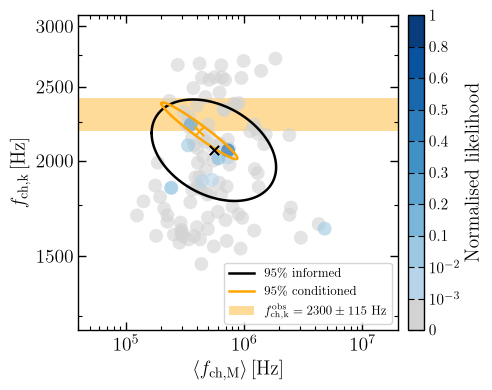

In [49]:
# The shaded horizontal band is the mock measurement, which is the one
# assumption in the figure; the black ellipse is the credible region the
# measurement starts from, that is the posterior of the fit, and the coloured
# one is the region left once the measurement has reweighted the ensemble.
# Everything inferred is a line and only the assumption is shaded.
fq_plot_eos_pairs(
    ellipse=True,
    power_law=False,
    measurement=fq_illustrative,
    credible=FQ_CREDIBLE,
    save="quadVsChar_conditioned.pdf",
)

## 7. `tnuc_likelihood.pdf` -- the nucleation time

The distribution of $t_{\rm nuc}$ over every PT scenario of the set, binned
logarithmically, with every column cut into the likelihood it is made of. A
model inherits the likelihood of its equation of state, and the scale is the
one of the whole set: the largest likelihood of the accepted sample is what
normalises every column.

The bands are disjoint, so the columns still count models and their total
height is the one of the plain histogram. Within a column the likeliest
models are laid at the bottom and the least likely, the grey ones, on top.

The two medians carry the colours and the dashes of the two fitted lines of
section 6: the unweighted reading is the prior, every PT scenario counting
alike; weighting by the likelihood is what makes it the posterior. And the
likelihood belongs to the equation of state, not to the scenario, so within a
single one of them the weight is one number and cancels exactly. The
weighting says something about the set as a whole and nothing whatever about
any one equation of state.

In [50]:
use_style(**{
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "figure.titlesize": 16,
})

# The twelfth column of "rows", in the order written by the Julia code
RS_T_NUC_COLUMN = ROW_COLUMNS.index("t_nuc_ms")

rs_t_nuc_parts = []
rs_likelihood_parts = []

for key, likelihood, data in gw_groups("rows"):
    rows = data["rows"]

    rs_t_nuc_parts.append(rows[:, RS_T_NUC_COLUMN])

    rs_likelihood_parts.append(np.full(rows.shape[0], likelihood))

rs_t_nuc = np.concatenate(rs_t_nuc_parts)

# NaNs become 0 and small numerical excursions past either end are clipped
rs_likelihood = gw_normalize(np.concatenate(rs_likelihood_parts))

print(f"{rs_t_nuc.size:,} PT scenarios")

print(
    f"t_nuc = {rs_t_nuc.mean():.0f} +/- {rs_t_nuc.std():.0f} ms   "
    "(mean and standard deviation)"
)

print(
    f"        {np.percentile(rs_t_nuc, 16):.0f} to "
    f"{np.percentile(rs_t_nuc, 84):.0f} ms   (16th to 84th percentile)"
)

9,616 PT scenarios
t_nuc = 616 +/- 801 ms   (mean and standard deviation)
        77 to 1336 ms   (16th to 84th percentile)


In [51]:
def rs_decade_ticks(axis):
    """Labels at every decade, unlabelled minor ticks at 2, 3, ..., 9."""
    axis.set_major_locator(LogLocator(base=10.0, numticks=100))
    axis.set_major_formatter(LogFormatterMathtext(base=10.0))

    axis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
    )
    axis.set_minor_formatter(NullFormatter())


def rs_style(ax, log_x=False, log_y=False):
    """Ticks and frame in the style of the other sections."""
    if log_x:
        ax.set_xscale("log")
        rs_decade_ticks(ax.xaxis)
    else:
        ax.minorticks_on()

    if log_y:
        ax.set_yscale("log")
        rs_decade_ticks(ax.yaxis)
    elif log_x:
        ax.yaxis.set_minor_locator(AutoMinorLocator())

    for which, length, width in (("major", 5, 0.8), ("minor", 3, 0.6)):
        ax.tick_params(
            axis="both",
            which=which,
            direction="in",
            length=length,
            width=width,
            left=True,
            right=True,
            bottom=True,
            top=True,
        )

    # Ticks and frame above the histogram rather than under it
    ax.set_axisbelow(False)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_zorder(20)


RS_BINS = 120

RS_TMIN = 3.0  # only 0.02% of the models nucleate sooner than this

RS_EDGES = np.logspace(np.log10(RS_TMIN), np.log10(rs_t_nuc.max()), RS_BINS)

RS_MEDIAN_LINE = 2.0

# The bands: one per bin of the likelihood colour scale, disjoint, so the
# columns still count models.
rs_bands = []

print(f"{'likelihood':>16s} {'scenarios':>10s} {'share':>8s}")

for index in range(len(LIKELIHOOD_COLOURS)):
    lower, upper = LIKELIHOOD_BOUNDS[index], LIKELIHOOD_BOUNDS[index + 1]

    last = index == len(LIKELIHOOD_COLOURS) - 1

    inside = (rs_likelihood >= lower) & (
        rs_likelihood <= upper if last else rs_likelihood < upper
    )

    rs_bands.append(rs_t_nuc[inside])

    print(
        f"  [{lower:>6g}, {upper:<6g}) {inside.sum():>10d}"
        f" {100 * inside.mean():>7.2f}%"
    )


RS_PLAIN_MEDIAN = float(np.median(rs_t_nuc))

RS_WEIGHTED_MEDIAN = float(weighted_quantile(rs_t_nuc, 0.5, rs_likelihood))

RS_MEDIANS = (
    (RS_WEIGHTED_MEDIAN, POSTERIOR_COLOUR, "--", "informed"),
    (RS_PLAIN_MEDIAN, PRIOR_COLOUR, ":", "uninformed"),
)

print(
    f"\n{rs_likelihood.size:,} PT scenarios, worth "
    f"{effective_size(rs_likelihood):,.0f} equally weighted ones"
)

print(f"median [ms]   unweighted {RS_PLAIN_MEDIAN:.4g}, weighted {RS_WEIGHTED_MEDIAN:.4g}")

      likelihood  scenarios    share
  [     0, 0.001 )       8766   91.16%
  [ 0.001, 0.01  )        421    4.38%
  [  0.01, 0.1   )        101    1.05%
  [   0.1, 0.2   )        142    1.48%
  [   0.2, 0.3   )         69    0.72%
  [   0.3, 0.4   )          0    0.00%
  [   0.4, 0.5   )          0    0.00%
  [   0.5, 0.6   )        117    1.22%
  [   0.6, 0.8   )          0    0.00%
  [   0.8, 1     )          0    0.00%

9,616 PT scenarios, worth 255 equally weighted ones
median [ms]   unweighted 273, weighted 624.7


saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\tnuc_likelihood.pdf


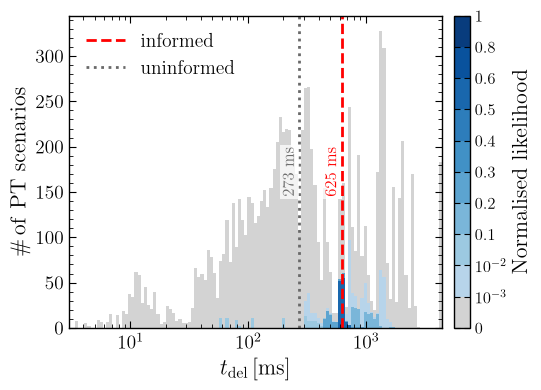

In [52]:
fig, ax = plt.subplots(figsize=(5.5, 4))

# Reversed, so the likeliest scenarios sit at the bottom of every column and
# the grey ones ride on top
ax.hist(
    rs_bands[::-1],
    bins=RS_EDGES,
    stacked=True,
    histtype="stepfilled",
    color=LIKELIHOOD_COLOURS[::-1],
    zorder=2,
)

for value, colour, dashes, name in RS_MEDIANS:
    ax.axvline(
        value,
        color=colour,
        lw=RS_MEDIAN_LINE,
        ls=dashes,
        zorder=3,
        label=rf"${{\rm {name}}}$",
    )

    # The legend names the line and this writes its value up the line itself,
    # so the number stays where the reader is already looking. The offset is in
    # points rather than in data units, which keeps it the same distance from
    # the line on any axis and any window.
    ax.annotate(
        rf"${value:.0f}~{{\rm ms}}$",
        xy=(value, 0.5),
        xycoords=ax.get_xaxis_transform(),
        xytext=(-7, 0),
        textcoords="offset points",
        rotation=90,
        ha="center",
        va="center",
        color=colour,
        fontsize=12,
        zorder=21,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )

# A bar of this aspect is as tall as the axes only if it is wide enough: the
# 0.025 of section 4 suits a figure twice as wide as this one, and here it
# would leave the bar floating half way up the side.
add_likelihood_colorbar(
    fig,
    ax,
    fraction=0.05,
    pad=0.03,
    labelsize=12,
    aspect=20,
)

rs_style(ax, log_x=True)

ax.set_xlim(RS_TMIN, RS_EDGES[-1])

ax.set_xlabel(r"$t_{\rm del}\,[\mathrm{ms}]$")
ax.set_ylabel(r"$\#\,{\rm of~PT~scenarios}$")
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()

save_figure(fig, "tnuc_likelihood.pdf")

plt.show()

## 8. `strainCurves.pdf` -- the spectra themselves

The ensemble is drawn in two layers, because its two halves need very
different treatment. Every curve below the first bin of the colour map is
painted in the same grey, and those are about ninety per cent of the
ensemble. They only have to resolve the shape of the envelope, so they are
rasterized by hand onto a grid: each cell keeps the largest normalized
likelihood among the curves crossing it, which is exactly the colour a line
plot would have left on top there. The minority above the threshold carries
what the figure is actually about and is drawn as real, anti-aliased lines on
top of that grid.

`SC_DRAFT_LIKELIHOOD` is the smallest normalized likelihood that is read at
all. Set it to 0.8 for a figure that comes out in seconds while the layout is
being adjusted, and back to 0.0 for the figure of the paper. Nothing else has
to change with it: the colour scale is normalized by the largest likelihood of
the whole set, read from `like_range` rather than from what was loaded, and
the spectrum of the inset is read on its own.

In [53]:
# The canvas below is 9 x 6 in, but the figure is printed at the width of one
# column, which section 4 fills from a 5 x 4 in canvas. The sizes here are
# therefore set larger than in the other sections, so that the text of the two
# figures comes out the same size on the page.
use_style(**{
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "axes.labelsize": 21,
    "axes.titlesize": 21,
    "legend.fontsize": 21,
    "legend.title_fontsize": 12,
    "figure.titlesize": 24,
})

SC_DRAFT_LIKELIHOOD = 0.0

sc_frequency_parts = []

sc_strain_parts = []

sc_likelihood_parts = []

sc_number_of_eos = 0

for key, likelihood, data in gw_groups("curves"):

    if gw_normalize(likelihood) < SC_DRAFT_LIKELIHOOD:
        continue

    curves = data["curves"]

    # Axis 1 holds the frequency in row 0 and the strain in row 1.
    sc_frequency_parts.append(curves[:, 0, :])

    sc_strain_parts.append(curves[:, 1, :])

    sc_likelihood_parts.append(np.full(curves.shape[0], likelihood))

    sc_number_of_eos += 1

sc_frequency = np.concatenate(sc_frequency_parts)

sc_strain = np.concatenate(sc_strain_parts)

sc_likelihood = np.concatenate(sc_likelihood_parts)

sc_number_of_curves, sc_number_of_points = sc_frequency.shape

sc_likelihood_normalized = gw_normalize(sc_likelihood)

print(
    f"{sc_number_of_curves:,} spectra of {sc_number_of_eos:,} equations of "
    f"state, sampled at {sc_number_of_points} points each, read from "
    f"{RESULTS.name}"
)

9,616 spectra of 110 equations of state, sampled at 21 points each, read from results_0.h5


In [54]:
# -----------------------------------------------------------------------------
# The density grid of the low-likelihood majority
# -----------------------------------------------------------------------------
# The density grid below is built over exactly the plotted window, so these two
# lines are the only place the axis ranges are defined.
SC_FREQUENCY_LIMITS = (1.0e4, 1.0e8)

SC_STRAIN_LIMITS = (1.0e-27, 1.0e-20)

sc_cmap, sc_bounds, sc_norm = likelihood_colormap()

SC_BACKGROUND_THRESHOLD = sc_bounds[1]  # top of the grey bin, 10^-3

SC_BACKGROUND_SHAPE = (1125, 1500)  # (strain rows, frequency columns)

# Thickness of the lines drawn for the high-likelihood curves.
SC_CURVE_LINEWIDTH = 0.6


def sc_density_grid(
    frequency,
    strain,
    weights,
    frequency_limits,
    strain_limits,
    shape,
    chunk_size=2000,
):
    """
    Rasterize an ensemble of curves onto a regular log-log grid.

    Each cell receives the largest weight among the curves passing through
    it. Cells that no curve reaches are left as NaN, so that they can be
    masked out and drawn transparent.
    """
    n_rows, n_columns = shape

    log_frequency_edges = np.linspace(
        np.log10(frequency_limits[0]),
        np.log10(frequency_limits[1]),
        n_columns + 1,
    )

    log_strain_edges = np.linspace(
        np.log10(strain_limits[0]),
        np.log10(strain_limits[1]),
        n_rows + 1,
    )

    column_width = log_frequency_edges[1] - log_frequency_edges[0]
    row_height = log_strain_edges[1] - log_strain_edges[0]

    log_frequency = np.log10(frequency)
    log_strain = np.log10(strain)

    # A segment joining two consecutive samples of a curve can span many
    # cells, which would leave holes along the steep parts of the spectrum.
    # Split every segment into enough sub-samples that the longest one
    # advances by at most one cell.
    segment_span = np.hypot(
        np.diff(log_frequency, axis=1) / column_width,
        np.diff(log_strain, axis=1) / row_height,
    )

    n_sub_samples = int(np.ceil(np.nanmax(segment_span))) + 1

    interpolation = np.linspace(0.0, 1.0, n_sub_samples)

    grid = np.full((n_rows, n_columns), np.nan)

    # Ascending weight, so that the highest-likelihood curves are written
    # last and therefore win wherever curves overlap.
    order = np.argsort(weights)

    # Chunked so that the sub-sampled coordinates never need more than a few
    # tens of megabytes at a time.
    for start in range(0, order.size, chunk_size):
        block = order[start:start + chunk_size]

        block_log_frequency = log_frequency[block]
        block_log_strain = log_strain[block]

        sub_frequency = (
            block_log_frequency[:, :-1, None]
            + np.diff(block_log_frequency, axis=1)[:, :, None] * interpolation
        )

        sub_strain = (
            block_log_strain[:, :-1, None]
            + np.diff(block_log_strain, axis=1)[:, :, None] * interpolation
        )

        columns = np.floor(
            (sub_frequency - log_frequency_edges[0]) / column_width
        ).astype(np.intp)

        rows = np.floor(
            (sub_strain - log_strain_edges[0]) / row_height
        ).astype(np.intp)

        inside = (
            (columns >= 0)
            & (columns < n_columns)
            & (rows >= 0)
            & (rows < n_rows)
        )

        block_weights = np.broadcast_to(
            weights[block][:, None, None],
            sub_frequency.shape,
        )

        grid[rows[inside], columns[inside]] = block_weights[inside]

    return grid


sc_is_background = sc_likelihood_normalized < SC_BACKGROUND_THRESHOLD


# Rasterizing the low-likelihood majority is by far the most expensive step of
# this section, so it lives here, in a cell of its own: the figure below can
# then be redrawn as often as needed without paying for it again. Re-run this
# cell after changing the plotted window, the shape of the grid, or the
# threshold, since the grid depends on all three.
sc_background = (
    sc_density_grid(
        sc_frequency[sc_is_background],
        sc_strain[sc_is_background],
        sc_likelihood_normalized[sc_is_background],
        SC_FREQUENCY_LIMITS,
        SC_STRAIN_LIMITS,
        SC_BACKGROUND_SHAPE,
    )
    if np.any(sc_is_background)
    else None
)

print(
    f"{int(np.count_nonzero(sc_is_background)):,} spectra in the grid, "
    f"{int(np.count_nonzero(~sc_is_background)):,} drawn as lines"
)

8,766 spectra in the grid, 850 drawn as lines


In [55]:
# -----------------------------------------------------------------------------
# The example spectrum of the inset
# -----------------------------------------------------------------------------
# The main panel shows the whole ensemble at once, which makes it hard to see
# the shape the ensemble is actually made of. This inset draws one curve on its
# own, over the same axis ranges as the main panel, so that its position and
# slope there can be read directly. It carries no ticks, numbers or labels: it
# is an illustration, not a second measurement.
#
# Any curve above the grey bin will do; this one belongs to the most likely
# equation of state of the set, whose normalized likelihood is 0.54. It is
# named by its group key and by which of that group's models it is -- rather
# than by its place in the pooled arrays, so that it is the same spectrum
# whatever SC_DRAFT_LIKELIHOOD is, and so that it is drawn even when its own
# equation of state falls under the threshold.
SC_EXAMPLE_CURVE = ("127", 25)

sc_example_key, sc_example_model = SC_EXAMPLE_CURVE

sc_example_curves = gw_group(sc_example_key, "curves")[1]["curves"]

sc_example_frequency = sc_example_curves[sc_example_model, 0, :]

sc_example_strain = sc_example_curves[sc_example_model, 1, :]

SC_EXAMPLE_COLOR = "red"

SC_EXAMPLE_LINEWIDTH = 2.0

# Marker drawn at the peak of the example curve.
SC_EXAMPLE_MARKER_SIZE = 6.0

# Position in axes coordinates: left, bottom, width, height. The width and
# height are given as equal fractions, which in axes coordinates makes the
# inset the same shape as the main panel whatever figsize is.
SC_INSET_POSITION = (0.552, 0.552, 0.408, 0.408)

# The frequency range is the one of the main panel, so that the curve keeps the
# position and slope it has there. The strain range is cropped at both ends --
# above the peak, where the main panel is empty anyway, and below the falling
# branch, which only has to show its slope, not run to the floor -- so that the
# curve and its labels sit centred in the box.
SC_INSET_STRAIN_LIMITS = (1.0e-25, 5.0e-23)
SC_INSET_FREQUENCY_LIMITS = (1.0e4, 1.0e7)

SC_DETECTOR_FONTSIZE = 18

SC_EXAMPLE_FONTSIZE = 18

saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\strainCurves.pdf


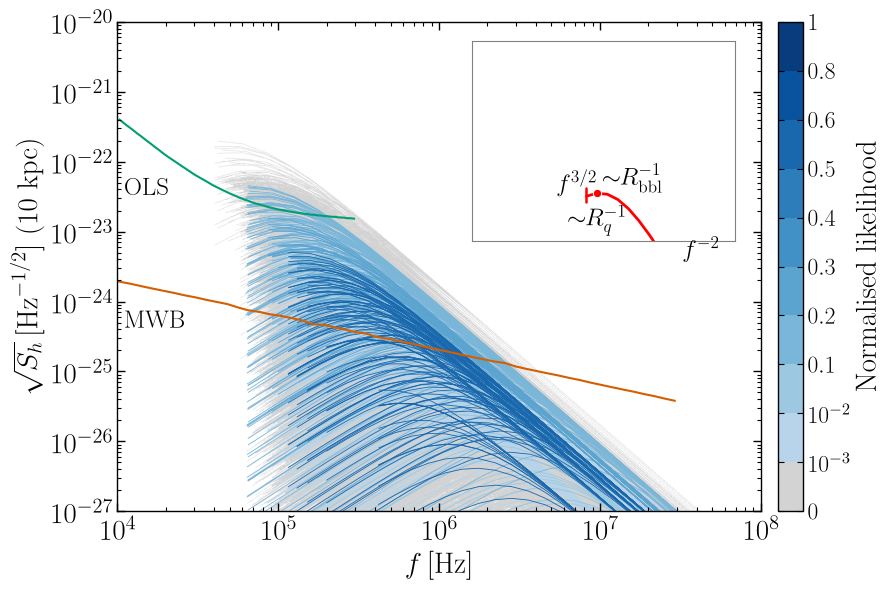

In [56]:
# -----------------------------------------------------------------------------
# The figure
# -----------------------------------------------------------------------------
# Everything below only draws: it reads the arrays prepared above and never
# recomputes them, so this cell can be re-run on its own while the layout is
# being tuned.
fig, ax = plt.subplots(figsize=(9, 6))

# The colorbar of the multi-band figure, drawn from the same colour map
add_likelihood_colorbar(
    fig,
    ax,
    fraction=0.05,
    pad=0.025,
    labelsize=17,
)

ax.set_xscale("log")
ax.set_yscale("log")

# The background image is placed in axes coordinates, which run from 0 to 1.
# Autoscaling would try to read those as data limits and complain about zero on
# a logarithmic axis, so the ranges are pinned here and set for real further
# down.
ax.set_autoscale_on(False)


# --- low-likelihood majority: the density grid computed above ----------------
if sc_background is not None:
    # Cells that no curve reaches are left transparent.
    sc_background_cmap = sc_cmap.copy()

    sc_background_cmap.set_bad(alpha=0.0)

    sc_background_image = ax.imshow(
        np.ma.masked_invalid(sc_background),
        origin="lower",
        # The grid is uniform in log10 and covers exactly the plotted window,
        # and the axes are logarithmic over that same window, so the grid maps
        # linearly onto the axes rectangle. Placing the image in axes
        # coordinates therefore lands it exactly where a pcolormesh over the
        # bin edges would, and lets Matplotlib resample it properly.
        extent=(0.0, 1.0, 0.0, 1.0),
        transform=ax.transAxes,
        aspect="auto",
        cmap=sc_background_cmap,
        norm=sc_norm,
        interpolation="antialiased",
        # Resample after coloring, so that the discrete bins of the colour map
        # are never averaged into colours that do not exist.
        interpolation_stage="rgba",
        zorder=1.0,
    )

    sc_background_image.set_clip_box(ax.bbox)

    sc_background_image.set_clip_on(True)


# --- high-likelihood minority: real lines ------------------------------------
sc_foreground = np.flatnonzero(~sc_is_background)

if sc_foreground.size:
    # Lowest likelihood first, so the most likely curves end up on top.
    sc_foreground = sc_foreground[
        np.argsort(sc_likelihood_normalized[sc_foreground])
    ]

    ax.add_collection(
        LineCollection(
            np.stack(
                (sc_frequency[sc_foreground], sc_strain[sc_foreground]),
                axis=-1,
            ),
            colors=sc_cmap(sc_norm(sc_likelihood_normalized[sc_foreground])),
            linewidths=SC_CURVE_LINEWIDTH,
            rasterized=True,
            zorder=2.0,
        ),
        autolim=False,
    )


# -----------------------------------------------------------------------------
# Detector sensitivity curves
# -----------------------------------------------------------------------------
# Only MWB and OLS reach the frequencies plotted here.
ax.loglog(
    mwbf,
    mwbstrain,
    color="#D55E00",
    linestyle="-",
    linewidth=1.5,
    label="MWB",
    zorder=10,
)

ax.loglog(
    levf,
    levstrain,
    color="#009E73",
    linestyle="-",
    linewidth=1.5,
    label="OLS",
    zorder=10,
)


# The two sensitivity curves are named on the panel itself rather than in a
# legend. Each name is anchored to its own curve at the left edge of the panel
# and written under it, so that the names keep their distance from the curves
# whatever the size of the type. MWB is the flat one of MWB-DMR-res.csv, and
# OLS the steep one of levitatedSensors_100m.csv.
def sc_name_detector(frequency, strain, text, offset):
    """Write the name of a sensitivity curve under its left end."""
    f0 = SC_FREQUENCY_LIMITS[0] * 1.1

    h0 = 10.0 ** np.interp(
        np.log10(f0),
        np.log10(frequency),
        np.log10(strain),
    )

    ax.text(
        f0,
        h0 / offset,
        text,
        fontsize=SC_DETECTOR_FONTSIZE,
        horizontalalignment="left",
        verticalalignment="top",
        zorder=11,
    )


# How far under its curve each name is written, as a factor in strain. OLS
# needs the larger drop of the two: its curve falls steeply, so a name written
# close under its left end is crossed by it a little further along.
sc_name_detector(levf, levstrain, r"${\rm~~OLS}$", 6.0)
sc_name_detector(mwbf, mwbstrain, r"${\rm MWB}$", 2.5)


# -----------------------------------------------------------------------------
# Axis ranges, labels and ticks
# -----------------------------------------------------------------------------
ax.set_xlim(*SC_FREQUENCY_LIMITS)
ax.set_ylim(*SC_STRAIN_LIMITS)

ax.set_xlabel(r"$f\,[\mathrm{Hz}]$")
ax.set_ylabel(r"$\sqrt{S_h}\,[\mathrm{Hz}^{-1/2}]~({\rm 10~kpc})$")

logarithmic_ticks(ax)


# -----------------------------------------------------------------------------
# The inset
# -----------------------------------------------------------------------------
inset = ax.inset_axes(SC_INSET_POSITION)

inset.loglog(
    sc_example_frequency,
    sc_example_strain,
    color=SC_EXAMPLE_COLOR,
    linewidth=SC_EXAMPLE_LINEWIDTH,
    solid_capstyle="round",
)

# Mark the peak of the spectrum.
sc_example_peak = np.argmax(sc_example_strain)

inset.plot(
    sc_example_frequency[sc_example_peak],
    sc_example_strain[sc_example_peak],
    marker="o",
    markersize=SC_EXAMPLE_MARKER_SIZE,
    color=SC_EXAMPLE_COLOR,
    markeredgecolor="white",
    markeredgewidth=0.7,
    linestyle="none",
    zorder=3,
)

inset.set_xlim(*SC_INSET_FREQUENCY_LIMITS)
inset.set_ylim(*SC_INSET_STRAIN_LIMITS)


# A short vertical tick at the leftmost sample of the curve, so that it is
# clear which frequency R_q^{-1} names.
sc_example_start_frequency = sc_example_frequency[0]

sc_example_start_strain = sc_example_strain[0]

inset.plot(
    [sc_example_start_frequency, sc_example_start_frequency],
    [sc_example_start_strain / 1.2, sc_example_start_strain * 1.3],
    color=SC_EXAMPLE_COLOR,
    linewidth=1.8,
    solid_capstyle="round",
    zorder=3,
)


# Symbols naming the features of the spectrum. Each one is anchored to a sample
# of the curve itself and then nudged by a multiplicative factor in frequency
# and in strain. Anchoring to the curve rather than to fixed coordinates keeps
# the labels on the line if SC_EXAMPLE_CURVE changes.
#
# The anchors are given as fractions of the rising and of the falling branch
# rather than as a number of samples, since how many samples a branch is made
# of is a property of the file: the final set writes twenty-one of them per
# spectrum where the earlier one wrote sixty-one.
sc_example_last_sample = sc_example_frequency.size - 1


def sc_example_sample(fraction, start, stop):
    """The sample a given fraction of the way from start to stop."""
    return int(round(start + fraction * (stop - start)))


# The two power laws sit outside the curve, above it; the two length scales sit
# inside, below it.
sc_example_labels = (
    # text, sample index, frequency factor, strain factor, ha, va
    (r"$\sim\!\!R_{q}^{-1}$", 0, 1.3, 0.75, "center", "top"),
    (
        r"$f^{3/2}$",
        sc_example_sample(0.5, 0, sc_example_peak),
        1.3,
        1.0,
        "right",
        "bottom",
    ),
    (r"$\sim\!\!R_{\rm bbl}^{-1}$", sc_example_peak, 2.5, 2.5, "center", "top"),
    (
        r"$f^{-2}$",
        sc_example_sample(0.32, sc_example_peak, sc_example_last_sample),
        1.80,
        0.7,
        "left",
        "bottom",
    ),
)

for text, sample, frequency_factor, strain_factor, ha, va in sc_example_labels:
    inset.text(
        sc_example_frequency[sample] * frequency_factor,
        sc_example_strain[sample] * strain_factor,
        text,
        color="black",
        fontsize=SC_EXAMPLE_FONTSIZE,
        horizontalalignment=ha,
        verticalalignment=va,
    )


# Strip every decoration: no ticks, no numbers, no labels.
inset.set_xticks([])
inset.set_yticks([])

inset.xaxis.set_minor_locator(plt.NullLocator())
inset.yaxis.set_minor_locator(plt.NullLocator())

# A thin frame and an opaque background keep the inset legible over the
# ensemble.
for spine in inset.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("0.5")

inset.patch.set_facecolor("white")
inset.patch.set_alpha(1.0)

# Above the ensemble and the detector curves.
inset.set_zorder(15)


plt.tight_layout()

save_figure(fig, "strainCurves.pdf")

plt.show()

## 9. `plotBubbles_crop.pdf` -- the bubble scan of one equation of state

The three scanned parameters of EOS 4272 -- the accretion rate, the surface
tension and the wall velocity -- with the number of bubbles for colour and
the bubble radius for size, and the three wall projections under them. The
file is the one exported from the Julia side.

The ticks sit on the sampled values themselves: the grid is coarse and
uneven, so a regular spacing would draw labels and wall lines where nothing
exists.

In [57]:
# The canvas below is 8.2 x 6.6 in, but the figure is printed at the width of
# one column, which section 4 fills from a 5 x 4 in canvas. The sizes here are
# therefore set larger than in the other sections, so that the text of the two
# figures comes out the same size on the page.
use_style(**{
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 15,
    "legend.title_fontsize": 16,
    "figure.titlesize": 24,
})

BB_LOG_COLOR = True       # N_bubbles spans ~4 decades; log reads far better
BB_CMAP = "viridis_r"
BB_D_LO, BB_D_HI = 4.0, 18.0   # marker-diameter range in points (maps R -> size)
BB_ELEV, BB_AZIM = 22, -58     # 3-D view angle
BB_PAD = 0.06                  # fractional axis-limit margin, hugging the data

BB_SHADOW_COLOR = "0.45"       # grey of the wall projections
BB_SHADOW_ALPHA = 0.12

BB_SHOW_TITLE = False          # sample id in the title -- off for the paper


with h5py.File(BUBBLES, "r") as h5:
    bb_accretion = h5["accretion"][:]        # M-dot  [Msun/s]   -> X
    bb_sigma = h5["sigma_MeV_fm2"][:]        # sigma  [MeV/fm^2] -> Y
    bb_v_wall = h5["v_wall"][:]              # v_w / c           -> Z
    bb_n_bubbles = h5["N_bubbles"][:]        # colour
    bb_r_bubble = h5["R_bubble_m"][:]        # marker size
    bb_f_peak = h5["fpeak_MHz"][:]           # size-legend annotation

    bb_sample_id = int(h5["meta/id"][()])
    bb_h5_id = int(h5["meta/h5_id"][()])
    bb_lambda_MeV = float(np.atleast_1d(h5["meta/Lambda_MeV"][()])[0])

print(
    f"sample {bb_sample_id} of {bb_h5_id}.h5  |  {bb_accretion.size} points  |  "
    f"Lambda = {bb_lambda_MeV:g} MeV"
)
print(f"R    : {bb_r_bubble.min():.4g} -- {bb_r_bubble.max():.4g} m")
print(f"N    : {bb_n_bubbles.min():.4g} -- {bb_n_bubbles.max():.4g}")

sample 883 of 0.h5  |  99 points  |  Lambda = 200 MeV
R    : 135.8 -- 2893 m
N    : 2.011 -- 1.849e+04


saved c:\Users\mauro\AppData\Local\Temp\ns_fopt_publish\results\figures\plotBubbles_crop.pdf


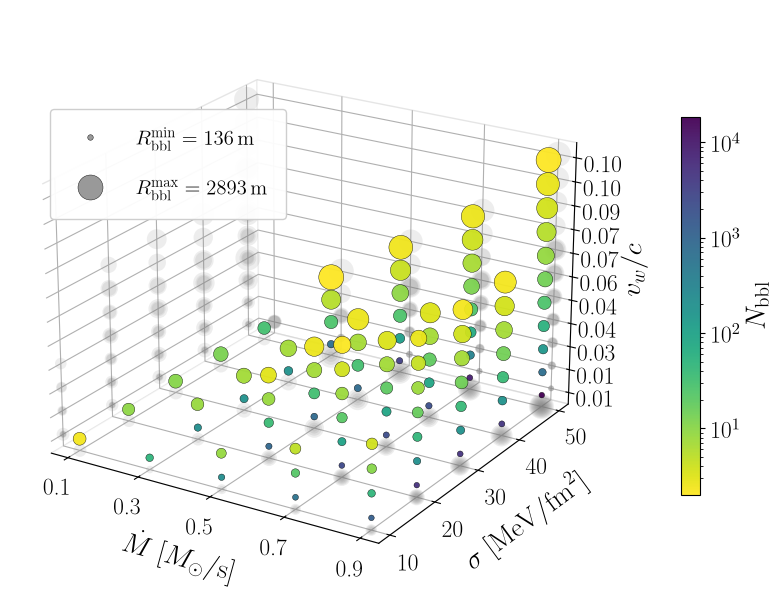

In [58]:
def bb_rescale(v, lo, hi, a, b):
    """Linear map v in [lo, hi] onto [a, b]."""
    return a + (b - a) * (v - lo) / (hi - lo)


# Marker sizes: linear R -> diameter, then square it (scatter wants area).
bb_r_lo, bb_r_hi = bb_r_bubble.min(), bb_r_bubble.max()

bb_diam = bb_rescale(bb_r_bubble, bb_r_lo, bb_r_hi, BB_D_LO, BB_D_HI)

bb_sizes = bb_diam ** 2

# Colour normalisation over N_bubbles.
bb_norm = (
    mcolors.LogNorm(vmin=bb_n_bubbles.min(), vmax=bb_n_bubbles.max())
    if BB_LOG_COLOR
    else mcolors.Normalize(vmin=bb_n_bubbles.min(), vmax=bb_n_bubbles.max())
)


# Axis limits hug the data (+/- BB_PAD) so the walls sit at fixed places and
# the shadows land exactly on them.
def bb_lims(v):
    lo, hi = v.min(), v.max()
    d = (hi - lo) * BB_PAD if hi > lo else abs(lo) * BB_PAD + 1e-12
    return lo - d, hi + d


bb_xlim, bb_ylim = bb_lims(bb_accretion), bb_lims(bb_sigma)

# v_w/c keeps its floor at 0 so the lowest samples sit just above the wall.
bb_zlim = (0.0, bb_v_wall.max() * (1.0 + BB_PAD))

# The sample grid is coarse and uneven, so tick every axis on the values that
# are actually there; the grey pane lines follow the ticks.
bb_xticks, bb_yticks, bb_zticks = (
    np.unique(v) for v in (bb_accretion, bb_sigma, bb_v_wall)
)

fig = plt.figure(figsize=(8.2, 6.6))
ax = fig.add_subplot(111, projection="3d")

# Wall projections: the same points with one coordinate pinned to a wall.
bb_shadow_kw = dict(
    s=bb_sizes,
    c=BB_SHADOW_COLOR,
    alpha=BB_SHADOW_ALPHA,
    edgecolors="none",
    depthshade=False,
    zorder=1,
)

# floor z=zmin  (Mdot-sigma)
ax.scatter(
    bb_accretion, bb_sigma, np.full_like(bb_v_wall, bb_zlim[0]), **bb_shadow_kw
)

# back  y=ymax  (Mdot-v_w)
ax.scatter(
    bb_accretion, np.full_like(bb_sigma, bb_ylim[1]), bb_v_wall, **bb_shadow_kw
)

# left  x=xmin  (sigma-v_w)
ax.scatter(
    np.full_like(bb_accretion, bb_xlim[0]), bb_sigma, bb_v_wall, **bb_shadow_kw
)

# The bubbles themselves.
bb_sc = ax.scatter(
    bb_accretion,
    bb_sigma,
    bb_v_wall,
    c=bb_n_bubbles,
    cmap=BB_CMAP,
    norm=bb_norm,
    s=bb_sizes,
    edgecolors="black",
    linewidths=0.3,
    alpha=0.95,
    depthshade=False,
    zorder=5,
)

ax.set_xlim(*bb_xlim)
ax.set_ylim(*bb_ylim)
ax.set_zlim(*bb_zlim)
ax.set_xticks(bb_xticks)
ax.set_yticks(bb_yticks)
ax.set_zticks(bb_zticks)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.zaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# The sampled v_w/c values crowd together at the bottom of the axis, closer
# than a label is tall now that the type is larger, so a number is drawn only
# where the previous one has cleared. The ticks, and the grey wall lines that
# follow them, stay at every sampled value.
bb_z_span = bb_zlim[1] - bb_zlim[0]
bb_z_labels = []
bb_z_labelled = None

for z in bb_zticks:
    if bb_z_labelled is None or (z - bb_z_labelled) / bb_z_span >= 0.08:
        bb_z_labels.append("%.2f" % z)
        bb_z_labelled = z
    else:
        bb_z_labels.append("")

ax.set_zticklabels(bb_z_labels)
ax.set_xlabel(r"$\dot{M}\;[M_\odot/\mathrm{s}]$", labelpad=11)
ax.set_ylabel(r"$\sigma\;[\mathrm{MeV}/\mathrm{fm}^2]$", labelpad=11)
ax.set_zlabel(r"$v_w/c$", labelpad=6)
ax.view_init(elev=BB_ELEV, azim=BB_AZIM)

# Transparent panes, light box edges.
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 0.0))

    axis.pane.set_edgecolor("0.8")

ax.grid(True)

# Colourbar: N_bubbles.
bb_cbar = fig.colorbar(bb_sc, ax=ax, shrink=0.6, pad=0.10)
bb_cbar.set_label(r"$N_\mathrm{bbl}$", fontsize=20)

# Size legend: smallest and largest bubble. A 3-D legend swatch cannot show a
# size ratio, so the markers are built at the true sizes.
bb_imin, bb_imax = int(np.argmin(bb_r_bubble)), int(np.argmax(bb_r_bubble))

bb_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="0.6",
        markeredgecolor="black",
        markeredgewidth=0.3,
        markersize=bb_diam[bb_imin],
        label=r"$R_{\rm bbl}^{\rm min}=%.0f\,{\rm m}$" % (bb_r_bubble[bb_imin]),
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="0.6",
        markeredgecolor="black",
        markeredgewidth=0.3,
        markersize=bb_diam[bb_imax],
        label=r"$R_{\rm bbl}^{\rm max}=%.0f\,{\rm m}$" % (bb_r_bubble[bb_imax]),
    ),
]

bb_leg = ax.legend(
    handles=bb_handles,
    loc="upper left",
    bbox_to_anchor=(0.05, 0.85),
    frameon=True,
    framealpha=0.95,
    labelspacing=1.4,
    borderpad=0.9,
    handletextpad=1.2,
    title="",
)

bb_leg.set_zorder(30)

if BB_SHOW_TITLE:
    ax.set_title(rf"Sample {bb_sample_id} of {bb_h5_id}.h5")

plt.tight_layout()

save_figure(fig, "plotBubbles_crop.pdf")

plt.show()